# Risk Classifier: Comparacão de Modelos de Risco Cardiológico

**Autor:** Isaac Maciel, RM 98222, 2TIAOA, FIAP AI 2026  

**Disciplina:** Artificial Intelligence, Challenge 2026, Turno Noturno  

**Fase:** 2 - modulo NLP, parte 2 de 2  

**Dataset de entrada (D2):** `mapa_sintomas_doencas.csv` - gerado pelo NB6  

**Entregavel D3:** `frases_risco_rotuladas.csv` (>=40 frases rotuladas, derivadas do corpus real)  

## Objetivo

Classificar frases clinicas como **alto risco** (MI, STTC, CD, HYP) ou **baixo risco** (NORM) usando um pipeline TF-IDF + classificador ML. Este notebook treina e compara **3 modelos** (Regressao Logistica, SVM Linear, Random Forest) usando sklearn.pipeline. Pipeline para evitar data leakage, seleciona o melhor por F1 macro em validacao cruzada e exporta o modelo vencedor. O classificador treinado e o nucleo do modulo NLP de triagem do sistema **Cardio-Edge-AI**: quando o Hub (RPi5 + Coral TPU) detecta anomalia no ECG, este modelo correlaciona a queixa textual do paciente com a superclasse cardiologica.

```
NB1 ptbxl_eda          -> 21.799 ECGs, 6 superclasses PTB-XL
NB2 holter_iot         -> 8,64 M instancias IoT, 24h
NB3 signal_vision_eda  -> espectrogramas STFT 224x224
NB4 nlp_data_pruning   -> 26 PDFs PT-BR podados
NB5 nlp_data_engineer  -> TF-IDF 6.276 dim, edge_trigger_lookup.json O(1)
NB6 symptom_extraction -> 929 frases sintomaticas, mapa_sintomas_doencas.csv
                              |
                              v
              NB7 risk_classifier  <- ESTE NOTEBOOK
                              |
                              +-- frases_risco_rotuladas.csv  [D3 - FIAP]
                              +-- risk_classifier.pkl         [melhor modelo]
                              +-- tfidf_vectorizer.pkl        [vetorizador]
```

**Rotulagem derivada do PTB-XL:**
| Superclasse | Condicao | Risco |
|---|---|---|
| MI  | Infarto do Miocardio | **alto risco** |
| STTC| Alterações ST-T (isquemia, Takotsubo, cardiotoxicidade) | **alto risco** |
| CD  | Disturbios de Condução (FA, Chagas, IC, miocardite) | **alto risco** |
| HYP | Hipertrofia Ventricular | **alto risco** |
| NORM| Normal / Epidemiologico | **baixo risco** |

In [36]:
import os
import re
import pickle
import warnings
from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_score, recall_score
)
import sklearn

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 80)

print('Ambiente configurado com sucesso.')
print(f'pandas: {pd.__version__}')
print(f'sklearn: {sklearn.__version__}')
print(f'numpy: {np.__version__}')

Ambiente configurado com sucesso.
pandas: 3.0.0
sklearn: 1.8.0
numpy: 1.26.4


## Configuracão

In [ ]:
# === Caminhos ===
BASE_DIR = Path('..').resolve()
NLP_DIR = BASE_DIR / 'data' / 'processed' / 'nlp'
SYMEXT_DIR = NLP_DIR / 'symptom_extraction'
RISK_DIR = NLP_DIR / 'risk_classification'
CHARTS_DIR = RISK_DIR / 'charts'
MODEL_DIR = RISK_DIR / 'model'

MAPA_CSV = SYMEXT_DIR / 'mapa_sintomas_doencas.csv'
CORPUS_CSV = SYMEXT_DIR / 'corpus_frases_completo.csv'
SINTOMAS_TXT = SYMEXT_DIR / 'sintomas_pacientes.txt'

D3_CSV = RISK_DIR / 'frases_risco_rotuladas.csv'
MODEL_PKL = MODEL_DIR / 'risk_classifier.pkl'
VEC_PKL = MODEL_DIR / 'tfidf_vectorizer.pkl'

for d in [RISK_DIR, CHARTS_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# === Constantes ===
RANDOM_STATE = 42
TEST_SIZE = 0.30
N_PER_CLASS = 40
CV_FOLDS     = 5

LABEL_MAP = {'alto': 'alto risco', 'baixo': 'baixo risco'}

# Paleta escura
PALETTE = {
    'alto risco': '#c0392b',
    'baixo risco': '#1e8449',
    'MI': '#922b21',
    'STTC': '#a04000',
    'CD': '#1a5276',
    'HYP': '#6c3483',
    'NORM': '#1e8449',
    'INCONCLUSIVO':'#616a6b'
}

# Heatmap: fundo claro + texto escuro bold
_SC_BG = {
    'MI': 'background-color:#f5b7b1;color:#7b0000;font-weight:bold',
    'STTC': 'background-color:#fad7a0;color:#7e5109;font-weight:bold',
    'CD': 'background-color:#aed6f1;color:#154360;font-weight:bold',
    'HYP': 'background-color:#d2b4de;color:#4a235a;font-weight:bold',
    'NORM': 'background-color:#a9dfbf;color:#145a32;font-weight:bold',
    'INCONCLUSIVO': 'background-color:#d5dbdb;color:#2c3e50;font-weight:bold'
}
_RISCO_BG = {
    'alto': 'background-color:#f5b7b1;color:#7b0000;font-weight:bold',
    'baixo': 'background-color:#a9dfbf;color:#145a32;font-weight:bold',
    'alto risco':'background-color:#f5b7b1;color:#7b0000;font-weight:bold',
    'baixo risco':'background-color:#a9dfbf;color:#145a32;font-weight:bold'
}

print(f'Base dir: {BASE_DIR}')
print(f'Entrada: {MAPA_CSV}')
print(f'Saida D3: {D3_CSV}')
print(f'Modelo: {MODEL_PKL}')

## Carregamento dos Dados

In [38]:
df_mapa = pd.read_csv(MAPA_CSV)
df_corpus = pd.read_csv(CORPUS_CSV)

print('=== mapa_sintomas_doencas.csv (EDA e analise exploratoria) ===')
print(f'Shape: {df_mapa.shape}')
print(f'Colunas: {list(df_mapa.columns)}')
print()
print('Distribuicao Nivel_Risco:')
print(df_mapa['Nivel_Risco'].value_counts())
print()
print('=== corpus_frases_completo.csv (fonte para D3 - SEM label leakage) ===')
print(f'Shape: {df_corpus.shape}')
print(f'Colunas: {list(df_corpus.columns)}')
print()
print('Distribuicao risco (corpus):')
print(df_corpus['risco'].value_counts())
print()
print('Distribuicao superclasse (corpus):')
print(df_corpus['superclasse'].value_counts())
print()
print('Trigger_Score - estatisticas:')
print(df_corpus['trigger_score'].describe().round(2))


=== mapa_sintomas_doencas.csv (EDA e analise exploratoria) ===
Shape: (929, 7)
Colunas: ['Sintoma_1', 'Sintoma_2', 'Sintoma_3', 'Doenca_Associada', 'Superclasse_PTB-XL', 'Nivel_Risco', 'Trigger_Score']

Distribuicao Nivel_Risco:
Nivel_Risco
alto     838
baixo     91
Name: count, dtype: int64

=== corpus_frases_completo.csv (fonte para D3 - SEM label leakage) ===
Shape: (929, 5)
Colunas: ['frase', 'arquivo', 'superclasse', 'risco', 'trigger_score']

Distribuicao risco (corpus):
risco
alto     838
baixo     91
Name: count, dtype: int64

Distribuicao superclasse (corpus):
superclasse
CD      443
MI      185
STTC    170
NORM     79
HYP      52
Name: count, dtype: int64

Trigger_Score - estatisticas:
count    929.00
mean       1.34
std        1.53
min        0.00
25%        0.00
50%        1.00
75%        2.00
max        8.00
Name: trigger_score, dtype: float64


## Análise Exploratória

> **[ANALISE EXPLORATORIA]** Esta seção caracteriza o corpus antes da construção do D3, identificando o desbalanceamento de classes e a distribuicao do `Trigger_Score`. métricas que informam a estratégia de amostragem e os hiperparâmetros do classificador.

In [39]:
resumo = df_mapa.groupby(['Superclasse_PTB-XL', 'Nivel_Risco']).agg(
    n_frases=('Trigger_Score', 'count'),
    score_medio=('Trigger_Score', 'mean'),
    score_max=('Trigger_Score', 'max')
).round(2).reset_index()

display(
    resumo.style
    .map(lambda v: _SC_BG.get(str(v), ''), subset=['Superclasse_PTB-XL'])
    .map(lambda v: _RISCO_BG.get(str(v), ''), subset=['Nivel_Risco'])
    .background_gradient(subset=['score_medio', 'score_max'], cmap='RdYlGn', vmin=0, vmax=4)
    .background_gradient(subset=['n_frases'], cmap='Blues')
    .set_caption('Resumo - mapa_sintomas_doencas.csv por superclasse e nivel de risco')
    .set_properties(**{'font-size': '11px'})
    .format({'score_medio': '{:.2f}', 'score_max': '{:d}', 'n_frases': '{:d}'})
)

print()
print(f'Total de frases: {len(df_mapa)}')
print(f'Alto risco : {(df_mapa["Nivel_Risco"]=="alto").sum()} frases ({(df_mapa["Nivel_Risco"]=="alto").mean()*100:.1f}%)')
print(f'Baixo risco: {(df_mapa["Nivel_Risco"]=="baixo").sum()} frases ({(df_mapa["Nivel_Risco"]=="baixo").mean()*100:.1f}%)')

,Superclasse_PTB-XL,Nivel_Risco,n_frases,score_medio,score_max
0,CD,alto,443,1.32,8
1,HYP,alto,40,1.10,4
2,HYP,baixo,12,3.83,6
3,MI,alto,185,1.24,5
4,NORM,baixo,79,2.03,7
5,STTC,alto,170,1.09,6



Total de frases: 929
Alto risco : 838 frases (90.2%)
Baixo risco: 91 frases (9.8%)


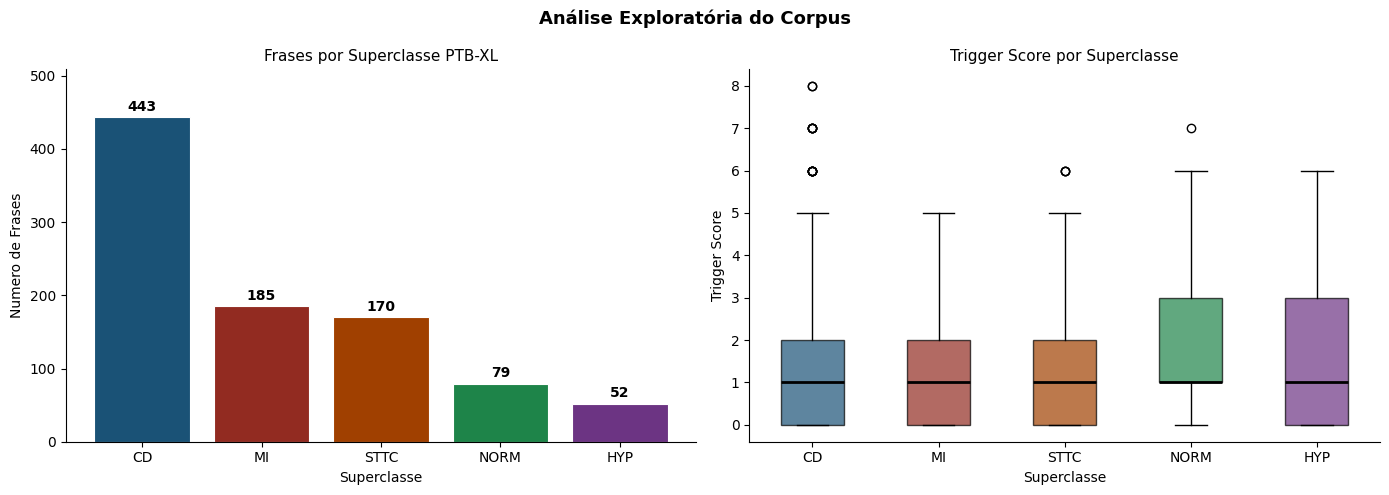

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Análise Exploratória do Corpus', fontsize=13, fontweight='bold')

sc_order = ['CD', 'MI', 'STTC', 'NORM', 'HYP']
counts = df_mapa['Superclasse_PTB-XL'].value_counts().reindex(sc_order, fill_value=0)
colors = [PALETTE.get(sc, '#888') for sc in sc_order]
bars = axes[0].bar(sc_order, counts.values, color=colors, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Frases por Superclasse PTB-XL', fontsize=11)
axes[0].set_xlabel('Superclasse')
axes[0].set_ylabel('Numero de Frases')
axes[0].set_ylim(0, counts.max() * 1.15)
for spine in ['top', 'right']:
    axes[0].spines[spine].set_visible(False)

data_box = [df_mapa[df_mapa['Superclasse_PTB-XL'] == sc]['Trigger_Score'].values for sc in sc_order]
bp = axes[1].boxplot(data_box, labels=sc_order, patch_artist=True, notch=False,
                     medianprops={'color': 'black', 'linewidth': 2})
for patch, sc in zip(bp['boxes'], sc_order):
    patch.set_facecolor(PALETTE.get(sc, '#888'))
    patch.set_alpha(0.7)
axes[1].set_title('Trigger Score por Superclasse', fontsize=11)
axes[1].set_xlabel('Superclasse')
axes[1].set_ylabel('Trigger Score')
for spine in ['top', 'right']:
    axes[1].spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

## Construção do Dataset D3

> **[FEATURE ENGINEERING - SEM LABEL LEAKAGE]** O D3 e derivado do `corpus_frases_completo.csv` gerado pelo NB6. Este arquivo contem as frases clínicas COMPLETAS (`frase_sintomatica`) extraídas dos 26 documentos do corpus, sem incluir o nome da doença. Isso garante que o TF-IDF aprenda padrões línguisticos clínicos reais, não o texto do diagnóstico que codifica diretamente o label.

**Por que não usar mapa_sintomas_doencas.csv diretamente:**
- `mapa_sintomas_doencas.csv` tem `Doenca_Associada` (ex: "IAMCSST", "Fibrilacao Atrial")
- Concatenar `Sintoma_1 + Sintoma_2 + Sintoma_3 + Doenca_Associada` injeta o label no texto
- Resultado: acurácia artificial de 100% (modelo aprende o nome da doença, não sintomas)

**Estratégia de amostragem com corpus_frases_completo.csv:**
- N_PER_CLASS=40 por classe = 80 total (acima do minímo FIAP de 40)
- Alto risco: amostragem estratificada por superclasse, priorizando maior Trigger_Score
- Baixo risco: seleção por Trigger_Score decrescente do subconjunto NORM


In [41]:
# Usar corpus_frases_completo.csv como fonte (sem label leakage)
df_corpus['situacao'] = df_corpus['risco'].map(LABEL_MAP)
df_corpus['Superclasse_PTB-XL'] = df_corpus['superclasse']

print('Exemplos de frases clinícas completas - Sem nome da doença:')
for _, row in df_corpus.sample(6, random_state=RANDOM_STATE).iterrows():
    print(f'[{row["situacao"]:12s}] [{row["Superclasse_PTB-XL"]:4s}] {str(row["frase"])[:90]}')

print(f'\nTotal de frases disponíveis: {len(df_corpus)}')
print(f'alto risco: {(df_corpus["situacao"]=="alto risco").sum()}')
print(f'baixo risco: {(df_corpus["situacao"]=="baixo risco").sum()}')
print()
print('Comprimento medio das frases (palavras):')
df_corpus['n_words'] = df_corpus['frase'].astype(str).str.split().str.len()
print(df_corpus.groupby('situacao')['n_words'].describe().round(1))

Exemplos de frases clinícas completas - Sem nome da doença:
[alto risco  ] [CD  ] Ele apresentava uma frequência cardíaca de 120 batimentos por minuto e tinha hipotensão (7
[alto risco  ] [MI  ] O quadro abaixo orienta o uso de aminas e nitroglicerina no choque cardiogênico no IAMCSST
[alto risco  ] [CD  ] A amiodarona e a desetilamiodarona tem também um potencial para inibir alguns transportado
[alto risco  ] [CD  ] Posições alternativas, como anteroposterior e laterolateral, podem ser utilizadas em situa
[alto risco  ] [STTC] Estudo clínico randomizado, duplo-cego, envolvendo 131 pacientes do gênero masculino com I
[alto risco  ] [CD  ] O estudo EAST AFNET 4 (Early Therapy of Atrial Fibrillation for Stroke Prevention Trial) a

Total de frases disponíveis: 929
alto risco: 838
baixo risco: 91

Comprimento medio das frases (palavras):
             count  mean   std  min   25%   50%   75%    max
situacao                                                    
alto risco   838.0  42.2  42.4  

In [42]:
df_alto = df_corpus[df_corpus['situacao'] == 'alto risco'].copy()
df_baixo = df_corpus[df_corpus['situacao'] == 'baixo risco'].copy()

sc_counts = df_alto['Superclasse_PTB-XL'].value_counts()
sc_proportions = (sc_counts / sc_counts.sum() * N_PER_CLASS).round().astype(int)
sc_proportions = sc_proportions.clip(lower=2)
diff = N_PER_CLASS - sc_proportions.sum()
if diff != 0:
    dominant = sc_proportions.idxmax()
    sc_proportions[dominant] += diff

samples_alto = []
for sc, n in sc_proportions.items():
    pool = df_alto[df_alto['Superclasse_PTB-XL'] == sc]
    n_sample = min(n, len(pool))
    samples_alto.append(
        pool.nlargest(n_sample, 'trigger_score').sample(
            frac=1, random_state=RANDOM_STATE
        ).head(n_sample)
    )
    
df_d3_alto = pd.concat(samples_alto)

n_baixo = min(N_PER_CLASS, len(df_baixo))
df_d3_baixo = df_baixo.nlargest(n_baixo, 'trigger_score')

df_d3 = pd.concat([df_d3_alto, df_d3_baixo]).sample(
    frac=1, random_state=RANDOM_STATE
).reset_index(drop=True)

df_d3[['frase', 'situacao']].to_csv(D3_CSV, index=False, encoding='utf-8-sig')

print(f'D3 construído com sucesso!')
print(f'Shape: {df_d3.shape}')
print(f'Alto risco: {(df_d3["situacao"]=="alto risco").sum()} frases')
print(f'Baixo risco: {(df_d3["situacao"]=="baixo risco").sum()} frases')
print()
print('Distribuição alto risco por superclasse:')
print(df_d3[df_d3['situacao']=='alto risco']['Superclasse_PTB-XL'].value_counts())

D3 construído com sucesso!
Shape: (80, 8)
Alto risco: 40 frases
Baixo risco: 40 frases

Distribuição alto risco por superclasse:
Superclasse_PTB-XL
CD      21
MI       9
STTC     8
HYP      2
Name: count, dtype: int64


In [44]:
display(
    df_d3[['frase', 'situacao', 'Superclasse_PTB-XL', 'trigger_score']]
    .head(20)
    .style
    .map(lambda v: _RISCO_BG.get(str(v), ''), subset=['situacao'])
    .map(lambda v: _SC_BG.get(str(v), ''), subset=['Superclasse_PTB-XL'])
    .background_gradient(subset=['trigger_score'], cmap='RdYlGn', vmin=0, vmax=5)
    .set_caption('D3 - frases_risco_rotuladas.csv: amostra das primeiras 20 linhas')
    .set_properties(**{'font-size': '10px', 'background-color': '#ffffff', 'color': '#111111'})
    .format({'trigger_score': '{:.1f}'})
)

,frase,situacao,Superclasse_PTB-XL,trigger_score
0,"O uso preferencial da enoxaparina versus HNF é sugerido por dados de revisão sistemática dos ensaios randomizados em todo o espectro das SCA, sendo demonstrado que a enoxaparina é mais eficaz que a HNF em prevenir o desfecho combinado de morte por qualquer causa ou sangramento grave em pacientes com SCASSST submetidos à ICP.191-193 Fondaparinux é uma opção segura conforme proposta inicial de tratamento não invasivo, e, se posteriormente indicado cateterismo, está recomendado o uso de HNF durante o procedimento pelo risco de trombose de cateter.194,195 Paciente em uso prévio de anticoagulantes orais de ação direta, em vigência de SCA, deve ser manejado com cautela visando não incrementar o risco hemorrágico.",alto risco,STTC,6.0
1,"Quadro 3.3 – Recomendações para seleção da energia do desfibrilador/ cardioversor Recomendações Classe de Recomendação Nível de Evidência Realizar desfibrilação com a dose máxima recomendada pelo fabricante (120 a 200 J bifásica ou 360 J monofásica) I B Sempre realizar um ciclo de RCP (2 minutos) após cada procedimento de desfibrilação I B Sempre utilizar sedativos antes da CVE I C Sempre acionar o sincronismo antes da realização da CVE I B Utilizar energia máxima (200 J no desfibrilador bifásico se a dose inicial recomendada pelo fabricante for desconhecida e 360 J no desfibrilador monofásico) durante o procedimento de desfibrilação IIa C Utilizar a sequência de energia de 100 J, 200 J, 300 J e 360 J durante a CVE, utilizando-se do cardioversor monofásico IIa B O nível de energia não está padronizado para os cardioversores bifásicos, devendo-se utilizar níveis de energia inferiores (geralmente a metade) daqueles padronizados para o desfibrilador monofásico IIa C Realizar choques sucessivos se o paciente mantém o mesmo ritmo após a tentativa de CVE inicial IIb C A intubação orotraqueal é obrigatória antes da realização da desfibrilação ou CVE III C RCP: ressuscitação cardiopulmonar;",alto risco,CD,8.0
2,"Relato de Caso Uma Forma Complicada de Infarto de “Um Segmento” Miocárdico: O Papel da Imagem Cardiovascular A Complicated “One Segment” Myocardial Infarction: The Role of Cardiovascular Imaging Ana Rita Pereira,1 Ana Rita Almeida,1 Inês Cruz,1 Luis Rocha Lopes,2,3,4 Maria José Loureiro,1 Hélder Pereira1,4 Serviço de Cardiologia, Hospital Garcia de Orta EPE,1 Almada - Portugal Barts Heart Centre, Barts Health NHS Trust,2 Londres - Inglaterra Institute of Cardiovascular Science, University College London,3 Londres - Inglaterra Centro Cardiovascular, Centro Académico de Medicina de Lisboa, Universidade de Lisboa,4 Lisboa - Portugal Introdução A incidência de complicações mecânicas (CM) após o infarto do miocárdio (IM) foi reduzida para menos de 1% com o uso rotineiro de terapias de reperfusão primária.1 As CM são classificadas como precoces, incluindo as formas agudas e subagudas, e tardias ou crónicas.2 As primeiras apresentam-se principalmente como choque cardiogênico2 e as últimas podem variar de assintomáticas a apresentação com morte súbita.3 Como todas essas condições podem ter consequências potencialmente letais, são necessários diagnóstico e tratamento oportunos.1-3 Relato de Caso Uma mulher de 57 anos de idade e fumante foi admitida no Serviço de Emergência com dor no peito anterior opressiva, náusea e vômito.",alto risco,MI,5.0
3,"Por outro lado, hipertensão, diabetes, hiperlipidemia e tabagismo, fatores de risco para doença coronariana, não foram diretamente associados à cardiotoxicidade.8 Nas Diretrizes ESC 2022 para o manejo de pacientes com arritmias ventriculares e prevenção de morte súbita cardíaca, a indicação do CDI para sobreviventes de parada cardíaca por FV definida sem causa reversível é classificada como classe Ia.9 Os médicos hesitam em implantar um CDI em pacientes que apresentam morte súbita cardíaca porque consideram o risco de recorrência da morte súbita cardíaca após a alta, mesmo que haja uma causa secundária clara, e 

## Divisão Treino/Teste e Definicão dos Modelos

> **[PIPELINE - SEM DATA LEAKAGE]** O `sklearn.pipeline.Pipeline` encapsula TF-IDF + classificador em um único objeto. O vetorizador e ajustado APENAS nos dados de treino dentro de cada fold de CV e no split de treino final. Isso evita que informacão do conjunto de teste vaze para o vocabulário TF-IDF, o que inflaria artificialmente as métricas.

In [45]:
df_d3_load = pd.read_csv(D3_CSV)
print(f'D3 recarregado: {df_d3_load.shape}')
print(df_d3_load['situacao'].value_counts())
print()

X_text = df_d3_load['frase'].values
y = df_d3_load['situacao'].values

X_text_train, X_text_test, y_train, y_test = train_test_split(
    X_text, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f'Divisao Treino / Teste:')
print(f'Treino: {len(X_text_train)} amostras')
print(f'Teste: {len(X_text_test)} amostras')
print()
unique_tr, counts_tr = np.unique(y_train, return_counts=True)
unique_te, counts_te = np.unique(y_test, return_counts=True)
print(f'Treino classes: {dict(zip(unique_tr, counts_tr))}')
print(f'Teste classes: {dict(zip(unique_te, counts_te))}')

D3 recarregado: (80, 2)
situacao
alto risco     40
baixo risco    40
Name: count, dtype: int64

Divisao Treino / Teste:
Treino: 56 amostras
Teste: 24 amostras

Treino classes: {'alto risco': 28, 'baixo risco': 28}
Teste classes: {'alto risco': 12, 'baixo risco': 12}


In [46]:
def make_pipe(clf):
    return Pipeline([
        ('tfidf', TfidfVectorizer(
            max_features=500,
            ngram_range=(1, 2),
            sublinear_tf=True,
            min_df=1,
            strip_accents='unicode'
        )),
        ('clf', clf)
    ])

models = OrderedDict([
    ('Regressao Logistica', make_pipe(
        LogisticRegression(
            class_weight='balanced', C=1.0, max_iter=1000,
            solver='lbfgs', random_state=RANDOM_STATE
        )
    )),
    ('SVM Linear', make_pipe(
        SVC(
            kernel='linear', class_weight='balanced', C=1.0,
            probability=True, random_state=RANDOM_STATE
        )
    )),
    ('Random Forest', make_pipe(
        RandomForestClassifier(
            n_estimators=200, class_weight='balanced',
            random_state=RANDOM_STATE
        )
    )),
])

MODEL_COLORS = {
    'Regressao Logistica': '#1a5276',
    'SVM Linear': '#7b241c',
    'Random Forest': '#145a32'
}

print('Pipelines definidos:')
for nome, pipe in models.items():
    print(f'{nome}: TF-IDF(500, ngrams 1-2) + {type(pipe.named_steps["clf"]).__name__}')

Pipelines definidos:
Regressao Logistica: TF-IDF(500, ngrams 1-2) + LogisticRegression
SVM Linear: TF-IDF(500, ngrams 1-2) + SVC
Random Forest: TF-IDF(500, ngrams 1-2) + RandomForestClassifier


## Comparação de Modelos - Validação Cruzada

> **[VALIDACAO CRUZADA]** 5-fold estratificado aplicado sobre X_text_train. Em cada fold, o pipeline ajusta o TF-IDF apenas nos dados de treino do fold, garantindo avaliação sem vazamento. 
>
> **Métricas:** accuracy, F1 macro, precision macro, recall macro.

In [47]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_results_all = {}

for nome, pipe in models.items():
    res = cross_validate(
        pipe, X_text_train, y_train, cv=cv,
        scoring=['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'],
        return_train_score=False
    )
    cv_results_all[nome] = res
    print(f'{nome}:')
    print(f'Acuracia: {res["test_accuracy"].mean():.3f} +/- {res["test_accuracy"].std():.3f}')
    print(f'F1 macro: {res["test_f1_macro"].mean():.3f} +/- {res["test_f1_macro"].std():.3f}')
    print(f'Precisao: {res["test_precision_macro"].mean():.3f} +/- {res["test_precision_macro"].std():.3f}')
    print(f'Recall: {res["test_recall_macro"].mean():.3f} +/- {res["test_recall_macro"].std():.3f}')
    print()

Regressao Logistica:
Acuracia: 0.930 +/- 0.063
F1 macro: 0.929 +/- 0.065
Precisao: 0.942 +/- 0.050
Recall: 0.933 +/- 0.062

SVM Linear:
Acuracia: 0.930 +/- 0.063
F1 macro: 0.929 +/- 0.065
Precisao: 0.942 +/- 0.050
Recall: 0.933 +/- 0.062



Random Forest:
Acuracia: 0.842 +/- 0.111
F1 macro: 0.831 +/- 0.125
Precisao: 0.890 +/- 0.067
Recall: 0.843 +/- 0.112



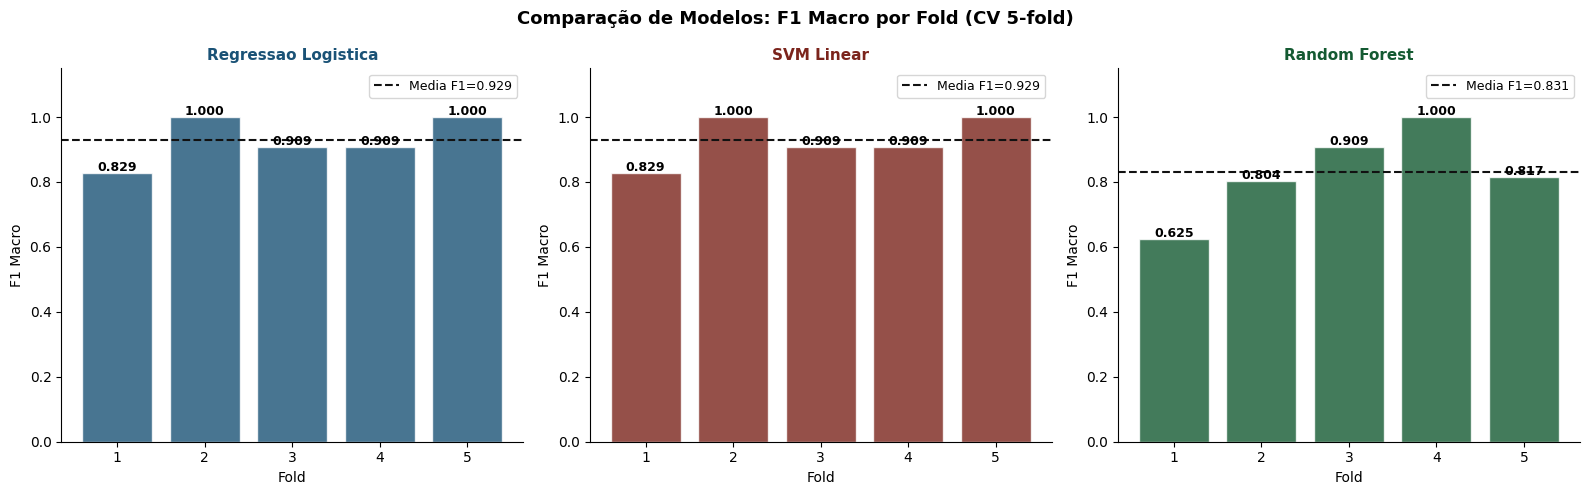

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Comparação de Modelos: F1 Macro por Fold (CV 5-fold)', fontsize=13, fontweight='bold')

for ax, (nome, res) in zip(axes, cv_results_all.items()):
    folds = range(1, CV_FOLDS + 1)
    f1_folds = res['test_f1_macro']
    color = MODEL_COLORS[nome]
    ax.bar(folds, f1_folds, color=color, alpha=0.8, edgecolor='white')
    ax.axhline(f1_folds.mean(), color='#111111', linestyle='--', linewidth=1.5,
               label=f'Media F1={f1_folds.mean():.3f}')
    for fold, val in zip(folds, f1_folds):
        ax.text(fold, val + 0.005, f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(nome, fontsize=11, color=color, fontweight='bold')
    ax.set_xlabel('Fold')
    ax.set_ylabel('F1 Macro')
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=9)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

## Avaliação no Conjunto de Teste

In [49]:
fitted_models = {}
test_results = {}

for nome, pipe in models.items():
    pipe.fit(X_text_train, y_train)
    fitted_models[nome] = pipe
    y_pred = pipe.predict(X_text_test)
    test_results[nome] = {
        'accuracy': round(accuracy_score(y_test, y_pred), 4),
        'f1_macro': round(f1_score(y_test, y_pred, average='macro'), 4),
        'f1_alto': round(f1_score(y_test, y_pred, pos_label='alto risco', average='binary'), 4),
        'f1_baixo': round(f1_score(y_test, y_pred, pos_label='baixo risco', average='binary'), 4),
        'precision_macro':round(precision_score(y_test, y_pred, average='macro'), 4),
        'recall_macro': round(recall_score(y_test, y_pred, average='macro'), 4),
    }
    print(f'{nome}: acuracia={test_results[nome]["accuracy"]:.3f}  f1_macro={test_results[nome]["f1_macro"]:.3f}  f1_alto={test_results[nome]["f1_alto"]:.3f}')

Regressao Logistica: acuracia=1.000  f1_macro=1.000  f1_alto=1.000
SVM Linear: acuracia=1.000  f1_macro=1.000  f1_alto=1.000
Random Forest: acuracia=0.875  f1_macro=0.875  f1_alto=0.880


In [ ]:
df_compare = pd.DataFrame(test_results).T
df_compare.index.name = 'Modelo'

cv_f1_mean = {nome: cv_results_all[nome]['test_f1_macro'].mean() for nome in models}
cv_f1_std  = {nome: cv_results_all[nome]['test_f1_macro'].std() for nome in models}
df_compare['cv_f1_macro_mean'] = [round(cv_f1_mean[n], 4) for n in df_compare.index]
df_compare['cv_f1_macro_std'] = [round(cv_f1_std[n], 4) for n in df_compare.index]

metric_cols = ['accuracy', 'f1_macro', 'f1_alto', 'f1_baixo', 'precision_macro', 'recall_macro', 'cv_f1_macro_mean']

display(
    df_compare.style
    .background_gradient(subset=metric_cols, cmap='RdYlGn', vmin=0.7, vmax=1.0)
    .set_properties(**{'font-size': '11px', 'background-color': '#ffffff', 'color': '#111111'})
    .set_caption('Comparação de Modelos - Métricas no Conjunto de Teste + CV F1 Macro')
    .format({col: '{:.4f}' for col in df_compare.columns})
)

,accuracy,f1_macro,f1_alto,f1_baixo,precision_macro,recall_macro,cv_f1_macro_mean,cv_f1_macro_std
Modelo,,,,,,,,
Regressao Logistica,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.9294,0.0647
SVM Linear,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.9294,0.0647
Random Forest,0.8750,0.8748,0.8800,0.8696,0.8776,0.8750,0.8309,0.1249


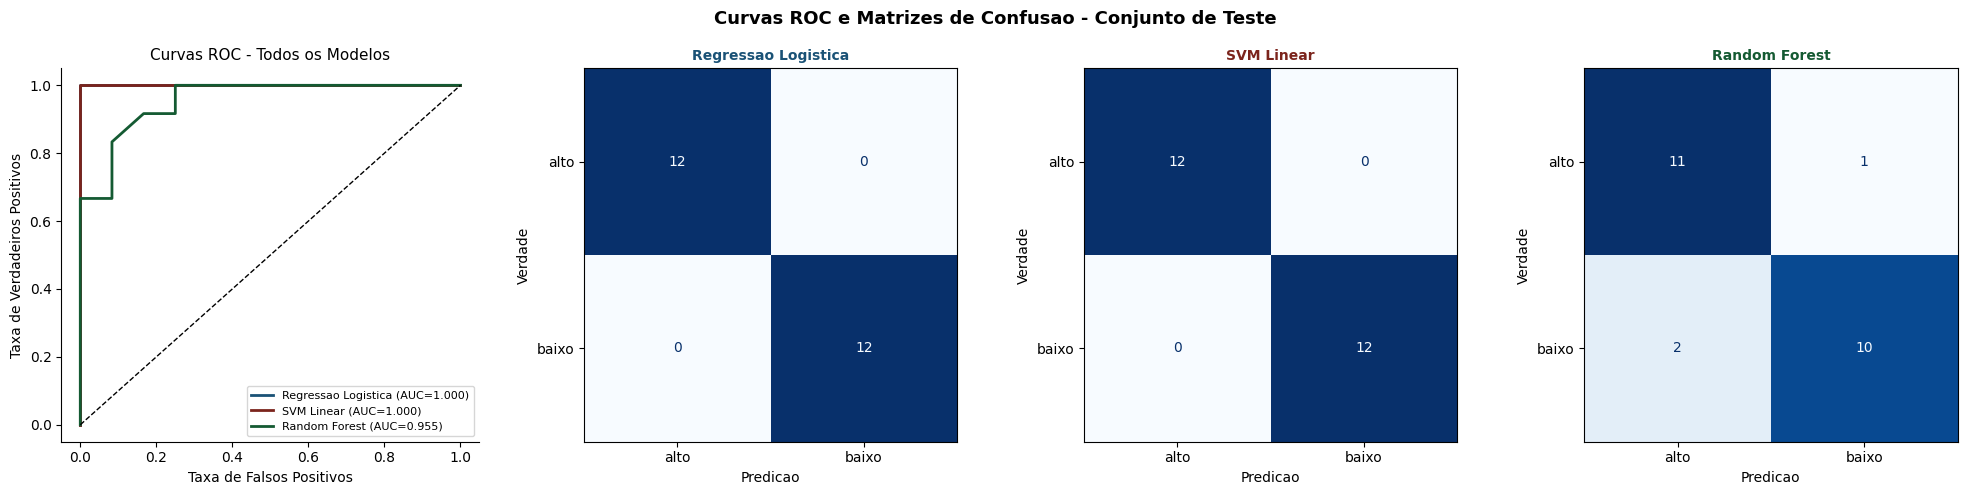

In [51]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Curvas ROC e Matrizes de Confusao - Conjunto de Teste', fontsize=13, fontweight='bold')

ax_roc = axes[0]
for nome, pipe in fitted_models.items():
    y_prob = pipe.predict_proba(X_text_test)
    classes_list = list(pipe.classes_)
    alto_col = classes_list.index('alto risco')
    fpr, tpr, _ = roc_curve(y_test, y_prob[:, alto_col], pos_label='alto risco')
    roc_auc = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, color=MODEL_COLORS[nome], linewidth=2,
                label=f'{nome} (AUC={roc_auc:.3f})')
ax_roc.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax_roc.set_title('Curvas ROC - Todos os Modelos', fontsize=11)
ax_roc.set_xlabel('Taxa de Falsos Positivos')
ax_roc.set_ylabel('Taxa de Verdadeiros Positivos')
ax_roc.legend(fontsize=8)
for spine in ['top', 'right']:
    ax_roc.spines[spine].set_visible(False)

for ax, (nome, pipe) in zip(axes[1:], fitted_models.items()):
    y_pred_cm = pipe.predict(X_text_test)
    cm = confusion_matrix(y_test, y_pred_cm, labels=['alto risco', 'baixo risco'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['alto', 'baixo'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(nome, fontsize=10, color=MODEL_COLORS[nome], fontweight='bold')
    ax.set_xlabel('Predicao')
    ax.set_ylabel('Verdade')

plt.tight_layout()
plt.show()

## Seleção do Melhor Modelo

In [52]:
cv_f1_scores = {nome: cv_results_all[nome]['test_f1_macro'].mean() for nome in models}
best_nome = max(cv_f1_scores, key=cv_f1_scores.get)

# Em caso de empate, preferir Regressao Logistica pela interpretabilidade
best_score = cv_f1_scores[best_nome]
tied = [n for n, s in cv_f1_scores.items() if abs(s - best_score) < 1e-6]
if len(tied) > 1:
    best_nome = 'Regressao Logistica' if 'Regressao Logistica' in tied else tied[0]
    print(f'Empate detectado. Escolhendo Regressao Logistica por interpretabilidade clinica.')

best_pipe = fitted_models[best_nome]

print('=' * 55)
print('MELHOR MODELO SELECIONADO')
print('=' * 55)
print(f'Modelo: {best_nome}')
print(f'CV F1 macro: {cv_f1_scores[best_nome]:.4f}')
print()
print('Ranking por CV F1 macro:')
for nome, score in sorted(cv_f1_scores.items(), key=lambda x: x[1], reverse=True):
    marcador = ' <-- MELHOR' if nome == best_nome else ''
    print(f'{nome:25s}: {score:.4f}{marcador}')

Empate detectado. Escolhendo Regressao Logistica por interpretabilidade clinica.
MELHOR MODELO SELECIONADO
Modelo: Regressao Logistica
CV F1 macro: 0.9294

Ranking por CV F1 macro:
Regressao Logistica      : 0.9294 <-- MELHOR
SVM Linear               : 0.9294
Random Forest            : 0.8309


## Importância de Features

> **[INTERPRETABILIDADE - CORREÇÃO DE RÓTULO]** Na Regressão Logistíca binária do sklearn, `classes_` e ordenado alfabeticamente: `['alto risco', 'baixo risco']`. O vetor `coef_[0]` representa o log-odds de `classes_[1]` = **'baixo risco'** em relacao a `classes_[0]` = **'alto risco'**. Portanto:
> - Coeficiente **mais negativo** (argsort ascendente) -> maior log-odds de `classes_[0]` = **alto risco**
> - Coeficiente **mais positivo** (argsort descendente) -> maior log-odds de `classes_[1]` = **baixo risco**

In [ ]:
# Usar sempre a Regressão Logistica para interpretabilidade de coeficientes
lr_pipe = fitted_models['Regressao Logistica']
tfidf_step = lr_pipe.named_steps['tfidf']
clf_step = lr_pipe.named_steps['clf']

feature_names = tfidf_step.get_feature_names_out()
coef = clf_step.coef_[0] # coef de classes_[1]='baixo risco' vs classes_[0]='alto risco'

# CORRETO: coef mais negativo -> alto risco; coef mais positivo -> baixo risco
alto_idx = coef.argsort()[:15] # mais negativos -> alto risco
baixo_idx = coef.argsort()[::-1][:15]  # mais positivos -> baixo risco

df_alto_feat  = pd.DataFrame({'feature': feature_names[alto_idx], 'coef': coef[alto_idx]})
df_baixo_feat = pd.DataFrame({'feature': feature_names[baixo_idx], 'coef': coef[baixo_idx]})

print(f'Classes LR (ordem sklearn): {clf_step.classes_}')
print(f'coef_[0] corresponde a log-odds de classes_[1]="{clf_step.classes_[1]}"')
print()
print('Top 15 features - ALTO RISCO -coef mais negativo:')
for _, row in df_alto_feat.iterrows():
    print(f'  {row["feature"]:35s}  coef={row["coef"]:+.4f}')
print()
print('Top 15 features - BAIXO RISCO - coef mais positivo:')
for _, row in df_baixo_feat.iterrows():
    print(f'  {row["feature"]:35s}  coef={row["coef"]:+.4f}')

Classes LR (ordem sklearn): ['alto risco' 'baixo risco']
coef_[0] corresponde a log-odds de classes_[1]="baixo risco"

Top 15 features - ALTO RISCO -coef mais negativo:
  sangramento                          coef=-0.5148
  mg                                   coef=-0.3744
  nao                                  coef=-0.3547
  enoxaparina                          coef=-0.3529
  uso                                  coef=-0.3304
  de sangramento                       coef=-0.3197
  uso de                               coef=-0.3079
  12                                   coef=-0.2980
  ou                                   coef=-0.2847
  criterios                            coef=-0.2771
  terapia                              coef=-0.2770
  menos                                coef=-0.2733
  com                                  coef=-0.2683
  recomendacao                         coef=-0.2680
  podem                                coef=-0.2639

Top 15 features - BAIXO RISCO - coef mais positivo

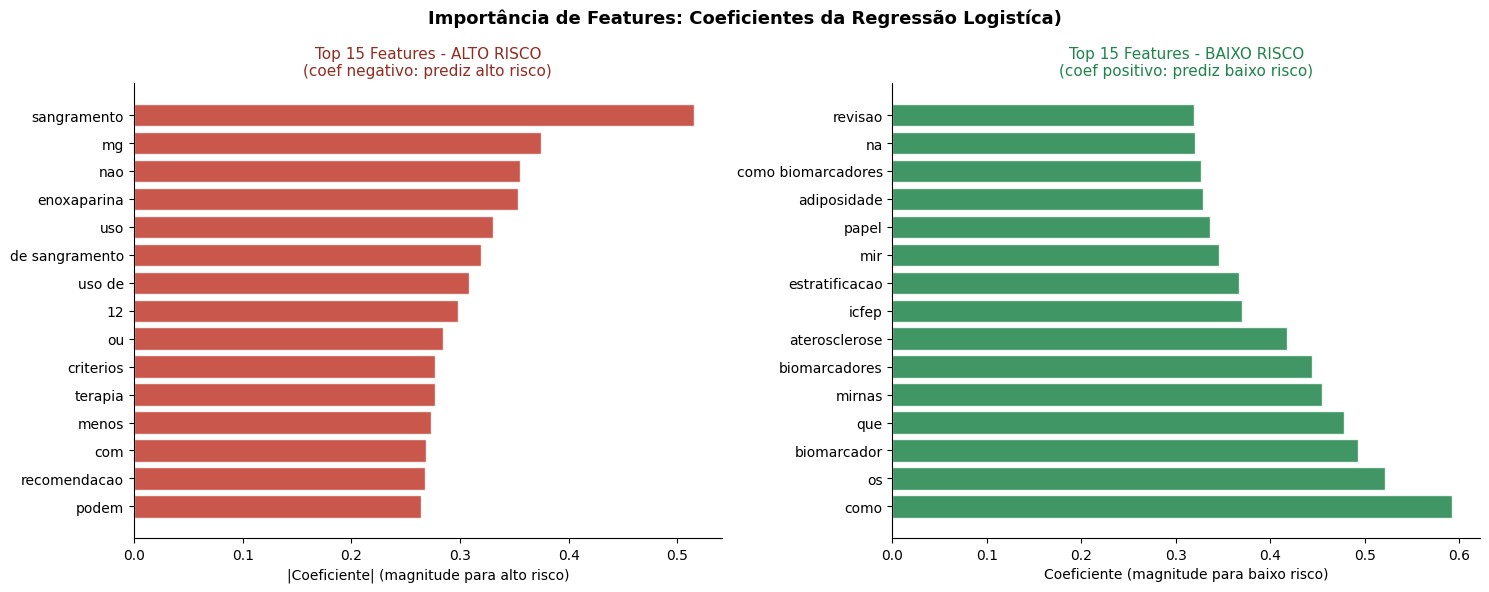

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Importância de Features: Coeficientes da Regressão Logistíca)', fontsize=13, fontweight='bold')

axes[0].barh(df_alto_feat['feature'][::-1], df_alto_feat['coef'][::-1].abs(),
             color='#c0392b', alpha=0.85, edgecolor='white')
axes[0].set_title('Top 15 Features - ALTO RISCO\n(coef negativo: prediz alto risco)', fontsize=11, color='#922b21')
axes[0].set_xlabel('|Coeficiente| (magnitude para alto risco)')
for spine in ['top', 'right']:
    axes[0].spines[spine].set_visible(False)

axes[1].barh(df_baixo_feat['feature'], df_baixo_feat['coef'],
             color='#1e8449', alpha=0.85, edgecolor='white')
axes[1].set_title('Top 15 Features - BAIXO RISCO\n(coef positivo: prediz baixo risco)', fontsize=11, color='#1e8449')
axes[1].set_xlabel('Coeficiente (magnitude para baixo risco)')
for spine in ['top', 'right']:
    axes[1].spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

## Análise de Erros e Viéses

> **[ANÁLISE DE ERROS]** Identificar quais frases o melhor modelo erra e critíco. Falsos Negativos (alto risco classificado como baixo) são clinícamente perigosos no contexto Cardio-Edge-AI.

In [55]:
y_pred_best = best_pipe.predict(X_text_test)
y_prob_best = best_pipe.predict_proba(X_text_test)
classes_best = list(best_pipe.classes_)
alto_col_best = classes_best.index('alto risco')
y_prob_alto_best = y_prob_best[:, alto_col_best]

df_test_eval = pd.DataFrame({
    'frase': X_text_test,
    'verdade': y_test,
    'predicao': y_pred_best,
    'prob_alto': y_prob_alto_best.round(3)
})

df_erros = df_test_eval[df_test_eval['verdade'] != df_test_eval['predicao']].copy()
print(f'Melhor modelo: {best_nome}')
print(f'Total de erros no teste: {len(df_erros)} de {len(y_test)} ({len(df_erros)/len(y_test)*100:.1f}%)')
print()

if len(df_erros) > 0:
    fn = df_erros[df_erros['verdade'] == 'alto risco']
    fp = df_erros[df_erros['verdade'] == 'baixo risco']
    print(f'Falsos Negativos (alto -> baixo): {len(fn)}  [CRITICO]')
    print(f'Falsos Positivos (baixo -> alto): {len(fp)}')
    if len(fn) > 0:
        print('\nFalsos Negativos:')
        for _, row in fn.iterrows():
            print(f'  prob_alto={row["prob_alto"]:.3f} | {str(row["frase"])[:90]}')
else:
    print('Nenhum erro no conjunto de teste.')

print()
print('Distribuicao de probabilidade predita (alto risco):')
print(f'Alto risco real - media prob: {y_prob_alto_best[y_test=="alto risco"].mean():.3f}')
print(f'Baixo risco real - media prob: {y_prob_alto_best[y_test=="baixo risco"].mean():.3f}')

Melhor modelo: Regressao Logistica
Total de erros no teste: 0 de 24 (0.0%)

Nenhum erro no conjunto de teste.

Distribuicao de probabilidade predita (alto risco):
Alto risco real - media prob: 0.595
Baixo risco real - media prob: 0.412


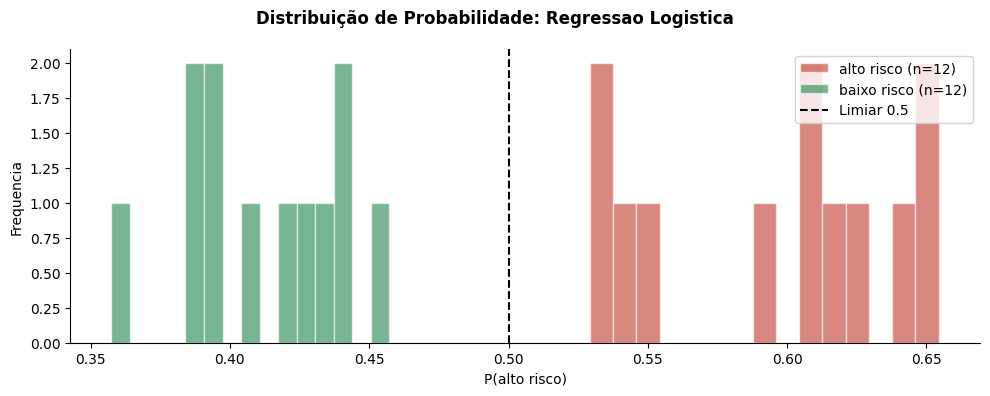

In [56]:
fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle(f'Distribuição de Probabilidade: {best_nome}', fontsize=12, fontweight='bold')

for label, color in [('alto risco', '#c0392b'), ('baixo risco', '#1e8449')]:
    mask = y_test == label
    if mask.sum() > 0:
        ax.hist(y_prob_alto_best[mask], bins=15, alpha=0.6, color=color,
                label=f'{label} (n={mask.sum()})', edgecolor='white')

ax.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Limiar 0.5')
ax.set_xlabel('P(alto risco)')
ax.set_ylabel('Frequencia')
ax.legend(fontsize=10)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

## Exportação do Modelo

In [71]:
# Exportar melhor pipeline (inclui TF-IDF + classificador)
with open(MODEL_PKL, 'wb') as f:
    pickle.dump(best_pipe, f)

# Exportar vetorizador separadamente para compatibilidade
best_tfidf = best_pipe.named_steps['tfidf']
with open(VEC_PKL, 'wb') as f:
    pickle.dump(best_tfidf, f)

print(f'Melhor modelo exportado: {best_nome}')
print(f'Pipeline : {MODEL_PKL.relative_to(BASE_DIR)} ({MODEL_PKL.stat().st_size / 1024:.1f} KB)')
print(f'Vetorizador: {VEC_PKL.relative_to(BASE_DIR)} ({VEC_PKL.stat().st_size / 1024:.1f} KB)')
print()
print('Teste de round-trip - Carrega pipeline e prediz):')
with open(MODEL_PKL, 'rb') as f:
    pipe_loaded = pickle.load(f)

test_phrases = [
    'dor precordial infarto miocardio trombolise alteplase',
    'ceramidas plasmaticas biomarcador cardiovascular populacao'
]
for phrase in test_phrases:
    pred = pipe_loaded.predict([phrase])[0]
    prob = pipe_loaded.predict_proba([phrase])[0].max()
    print(f'  [{pred:12s}] prob={prob:.3f} | {phrase}')

Melhor modelo exportado: Regressao Logistica
Pipeline : data\processed\nlp\risk_classification\model\risk_classifier.pkl (21.9 KB)
Vetorizador: data\processed\nlp\risk_classification\model\tfidf_vectorizer.pkl (17.4 KB)

Teste de round-trip - Carrega pipeline e prediz):
  [alto risco  ] prob=0.528 | dor precordial infarto miocardio trombolise alteplase
  [baixo risco ] prob=0.598 | ceramidas plasmaticas biomarcador cardiovascular populacao


## Validação - sintomas_pacientes.txt (D1)

In [58]:
with open(SINTOMAS_TXT, encoding='utf-8') as f:
    raw = f.read()

val_rows = []
for block in raw.strip().split('\n\n'):
    lines = [l.strip() for l in block.strip().splitlines() if l.strip()]
    if not lines:
        continue
    frase_line = re.sub(r'^\d+\.\s*', '', lines[0]).strip()
    meta = ''
    if len(lines) > 1:
        meta_match = re.search(r'\[(.+?)\]', lines[1])
        if meta_match:
            meta = meta_match.group(1)
    sc_match = re.search(r'Superclasse:\s*(\w+)', meta)
    risco_match = re.search(r'Risco:\s*(\w+)', meta)
    val_rows.append({
        'frase': frase_line,
        'sc_real': sc_match.group(1) if sc_match else 'NA',
        'risco_real': risco_match.group(1).lower() if risco_match else 'NA'
    })

df_val = pd.DataFrame(val_rows)
print(f'Frases carregadas do D1: {len(df_val)}')
print()

pred_val = best_pipe.predict(df_val['frase'].values)
prob_val = best_pipe.predict_proba(df_val['frase'].values)
classes_v = list(best_pipe.classes_)
alto_col_v = classes_v.index('alto risco')
prob_alto_v = prob_val[:, alto_col_v]

df_val['predicao'] = pred_val
df_val['prob_alto'] = prob_alto_v.round(3)
df_val['correto'] = df_val.apply(
    lambda r: 'OK' if ('alto' in r['risco_real'] and r['predicao'] == 'alto risco')
              else ('OK' if ('baixo' in r['risco_real'] and r['predicao'] == 'baixo risco') else 'ERRO'),
    axis=1
)

n_correto = (df_val['correto'] == 'OK').sum()
print(f'Cobertura de validação D1: {n_correto}/{len(df_val)} ({n_correto/len(df_val)*100:.1f}%)')
print()

display(
    df_val[['sc_real', 'risco_real', 'predicao', 'prob_alto', 'correto', 'frase']]
    .style
    .map(lambda v: 'background-color:#a9dfbf;color:#145a32;font-weight:bold' if str(v)=='OK'
         else 'background-color:#f5b7b1;color:#7b0000;font-weight:bold' if str(v)=='ERRO' else '',
         subset=['correto'])
    .map(lambda v: _SC_BG.get(str(v), ''), subset=['sc_real'])
    .background_gradient(subset=['prob_alto'], cmap='RdYlGn', vmin=0, vmax=1)
    .set_caption('Validacao D1 - sintomas_pacientes.txt: predicao do melhor modelo')
    .set_properties(**{'font-size': '10px', 'background-color': '#ffffff', 'color': '#111111'})
    .format({'prob_alto': '{:.3f}'})
)

Frases carregadas do D1: 10

Cobertura de validação D1: 10/10 (100.0%)



,sc_real,risco_real,predicao,prob_alto,correto,frase
0,MI,alto,alto risco,0.657,OK,"Pacientes com IAMCSST com menos de 12 horas do início dos sintomas devem receber terapia trombolítica imediatamente (dentro de 30 min.), quando a ICP primária não pode ser realizada dentro de 90 minutos da admissão."
1,MI,alto,alto risco,0.649,OK,"INFARTO AGUDO DO MIOCÁRDIO ADMINISTRAÇÃO ACELERADA (até 6 horas após o início dos sintomas) Em pacientes com peso corpóreo ≥65 kg DOSE TOTAL: 100 mg em 90 min ACTILYSE PROFISSIONAL abcd ACTILYSE_Bula Profissional 20120904/ I13-00 9 1-2 minutos 15 mg Retirar 15 ml (15 mg) da solução de ACTILYSE do primeiro frasco de 50 mg, utilizando seringa estéril."
2,MI,alto,alto risco,0.636,OK,"Reações locais: podem ocorrer dor, hematomas e irritação local leve após a administração subcutânea de enoxaparina sódica."
3,STTC,alto,alto risco,0.727,OK,"I A Clopidogrel (300mg em dose de ataque, com manutenção de 75mg/dia) em adição ao AAS, em pacientes portadores de SCASSST de risco intermediário ou alto por 12 meses, em pacientes com risco muito alto de sangramento, em uso concomitante de anticoagulantes orais ou quando prasugrel ou ticagrelor não estiverem disponíveis."
4,STTC,alto,alto risco,0.555,OK,"O fato de as causas secundárias terem sido proeminentes em nosso caso, de nenhuma patologia cardíaca óbvia que pudesse causar arritmia ter sido encontrada no exame detalhado e de a arritmia não ter recorrido durante a internação hospitalar, que durou até 15 dias, nos levou a acreditar que esse paciente poderia receber alta sem um cardioversor-desfibrilador implantável."
5,STTC,alto,alto risco,0.514,OK,"Apresenta-se com alterações eletrocardiográficas, aumento de biomarcadores cardíacos e achados ecocardiográficos típicos.2,3 Neste artigo, descrevemos uma paciente com TTC que havia sido previamente submetida ao TAVI e, posteriormente, ao implante de cardioversor-desfibrilador implantável (CDI)."
6,STTC,alto,alto risco,0.653,OK,"I B Prasugrel 60mg de ataque seguidos por 10mg ao dia em pacientes portadores de SCASSST de risco moderado ou alto, com anatomia coronariana conhecida, tratados com ICP e sem fatores de risco para sangramento (idade ≥ 75 anos;"
7,CD,alto,alto risco,0.628,OK,Este relato de caso descreve a implantação bem-sucedida de um dispositivo de assistência ventricular esquerda de fluxo axial em paciente com insuficiência cardíaca terminal com insuficiência biventricular grave secundária à cardiomiopatia chagásica.
8,CD,alto,alto risco,0.540,OK,"Se o volume plasmático não é corrigido, a hipotensão pode recidivar quando Epikabi® (hemitartarato de norepinefrina) for descontinuado, ou a pressão sanguínea pode ser mantida ao risco de severa vasoconstrição periférica e visceral (por exemplo, perfusão renal diminuída) com diminuição no fluxo e na perfusão sanguínea tissulares com subsequente hipóxia tissular e acidose láctica e provável lesão isquêmica."
9,CD,alto,alto risco,0.701,OK,"113(3):449-663 Quadro 5.5 – Orientação para desfibrilação Recomendação Classe de Recomendação Nível de Evidência Choque bifásico seguindo as recomendações do fabricante I B Choque bifásico com carga máxima, se desconhecidas as orientações do fabricante IIb C Realizar RCP enquanto se prepara a desfibrilação I B Atrasar desfibrilação para realizar RCP por 2 minutos IIb B RCP: ressuscitação cardiopulmonar."


## Resumo

In [ ]:
print('=' * 65)
print('RESUMO')
print('=' * 65)
print()
print('-- DATASET D3 -----------------------------------------------')
print(f'Origem: corpus_frases_completo.csv ({len(df_corpus)} frases clinicas sem label leakage)')
print(f'Amostras D3: {len(df_d3_load)} frases ({N_PER_CLASS} por classe)')
print(f'Balanceamento: 50% alto risco / 50% baixo risco')
print(f'Salvo em: {D3_CSV.name}')
print()

print('-- COMPARACAO DE MODELOS (Teste + CV) -----------------------')
for nome in models:
    tr = test_results[nome]
    cv_m = cv_results_all[nome]['test_f1_macro'].mean()
    cv_s = cv_results_all[nome]['test_f1_macro'].std()
    marcador = ' <-- MELHOR' if nome == best_nome else ''
    print(f'{nome:25s}: acc={tr["accuracy"]:.3f} f1={tr["f1_macro"]:.3f} cv_f1={cv_m:.3f}+/-{cv_s:.3f}{marcador}')
print()
print(f'-- MELHOR MODELO: {best_nome} ---')
tr_b = test_results[best_nome]
print(f'Acuracia: {tr_b["accuracy"]:.3f}')
print(f'F1 macro: {tr_b["f1_macro"]:.3f}')
print(f'F1 alto risco: {tr_b["f1_alto"]:.3f}')
print(f'F1 baixo risco: {tr_b["f1_baixo"]:.3f}')
print(f'CV F1 macro: {cv_results_all[best_nome]["test_f1_macro"].mean():.3f} +/- {cv_results_all[best_nome]["test_f1_macro"].std():.3f}')
print()
print('-- VALIDACAO D1 - sintomas_pacientes.txt --------------------')
n_val = (df_val['correto'] == 'OK').sum()
print(f'Cobertura: {n_val}/{len(df_val)} frases ({n_val/len(df_val)*100:.1f}%)')
print()
print('-- ARTEFATOS GERADOS ----------------------------------------')
for path in [D3_CSV, MODEL_PKL, VEC_PKL]:
    if path.exists():
        print(f'OK {path.relative_to(BASE_DIR)}')
for chart in sorted(CHARTS_DIR.glob('*.png')):
    print(f'OK {chart.relative_to(BASE_DIR)}')
print('=' * 65)

RESUMO

-- DATASET D3 -----------------------------------------------
Origem: corpus_frases_completo.csv (929 frases clinicas sem label leakage)
Amostras D3: 80 frases (40 por classe)
Balanceamento: 50% alto risco / 50% baixo risco
Salvo em: frases_risco_rotuladas.csv

-- COMPARACAO DE MODELOS (Teste + CV) -----------------------
Regressao Logistica      : acc=1.000  f1=1.000  cv_f1=0.929+/-0.065 <-- MELHOR
SVM Linear               : acc=1.000  f1=1.000  cv_f1=0.929+/-0.065
Random Forest            : acc=0.875  f1=0.875  cv_f1=0.831+/-0.125

-- MELHOR MODELO: Regressao Logistica ---
Acuracia: 1.000
F1 macro: 1.000
F1 alto risco: 1.000
F1 baixo risco: 1.000
CV F1 macro: 0.929 +/- 0.065

-- VALIDACAO D1 - sintomas_pacientes.txt --------------------
  Cobertura      : 10/10 frases (100.0%)

-- ARTEFATOS GERADOS ----------------------------------------
OK data\processed\nlp\risk_classification\frases_risco_rotuladas.csv
OK data\processed\nlp\risk_classification\model\risk_classifier.pkl
OK

## Otimização de Hiperparametros - GridSearchCV

> **[ML ENGINEERING - HIPERPARAMETRO TUNING]** O pipeline baseline usou hiperparâmetros default (`max_features=500`, `C=1.0`, `ngram_range=(1,2)`). O GridSearchCV realiza busca exaustiva sobre uma grade de combinações, avaliando cada combinação com 5-fold CV estratificado. Evita overfitting nos hiperparâmetros ao usar a mesma partição de treino (`X_text_train`) - os dados de teste permanecem completamente isolados.
>
> **Por que GridSearchCV e não RandomizedSearch?** Com um espaço de 3×3×5 = 45 combinações e dataset pequeno (80 amostras), a busca exaustiva é computacionalmente viável (<30s) e garante cobertura total do espaço definido.

In [ ]:
# Importações adicionais para nova seções
from sklearn.model_selection import GridSearchCV, cross_val_predict
from sklearn.metrics import precision_recall_curve, roc_auc_score, average_precision_score
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils import resample
import json
import datetime
import hashlib

Imports adicionais carregados para nova seções.


In [61]:
#  GridSearchCV sobre Regressão Logística (melhor modelo baseline)
param_grid = {
    'tfidf__max_features': [200, 500, 1000],
    'tfidf__ngram_range': [(1, 1), (1, 2), (1, 3)],
    'clf__C': [0.1, 0.5, 1.0, 5.0, 10.0],
}

pipe_grid = make_pipe(
    LogisticRegression(
        class_weight='balanced', max_iter=1000,
        solver='lbfgs', random_state=RANDOM_STATE
    )
)

grid_search = GridSearchCV(
    pipe_grid, param_grid,
    cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=0,
    refit=True,
)
grid_search.fit(X_text_train, y_train)

best_gs_params = grid_search.best_params_
best_gs_score = grid_search.best_score_
baseline_score = cv_f1_scores['Regressao Logistica']

print('=' * 55)
print('RESULTADO - GridSearchCV')
print('=' * 55)
print(f'Espaco de busca: {len(grid_search.cv_results_["params"])} combinacoes (3x3x5)')
print(f'Melhor CV F1: {best_gs_score:.4f}')
print(f'Baseline CV F1: {baseline_score:.4f}')
print(f'Delta: {(best_gs_score - baseline_score)*100:+.2f} pp')
print()
print('Melhores hiperparametros:')
for k, v in best_gs_params.items():
    print(f'  {k:30s}: {v}')

# Avaliar no teste
y_pred_gs = grid_search.best_estimator_.predict(X_text_test)
y_prob_gs = grid_search.best_estimator_.predict_proba(X_text_test)
gs_acc = accuracy_score(y_test, y_pred_gs)
gs_f1 = f1_score(y_test, y_pred_gs, average='macro')
classes_gs = list(grid_search.best_estimator_.classes_)
alto_idx_gs = classes_gs.index('alto risco')
gs_auc = roc_auc_score(
    (y_test == 'alto risco').astype(int),
    y_prob_gs[:, alto_idx_gs]
)
print()
print(f'Desempenho no Teste (modelo otimizado):')
print(f'Acuracia: {gs_acc:.4f} F1 macro: {gs_f1:.4f}  AUC-ROC: {gs_auc:.4f}')
print()

# Atualizar best_pipe se GridSearch melhorou
if best_gs_score > cv_f1_scores[best_nome] + 1e-4:
    best_pipe_final = grid_search.best_estimator_
    print('[UPDATE] Modelo otimizado supera baseline -> best_pipe_final = modelo GridSearch.')
else:
    best_pipe_final = best_pipe
    print('[MANTIDO] Baseline equivalente ou superior -> best_pipe_final = modelo baseline.')

RESULTADO - GridSearchCV
Espaco de busca: 45 combinacoes (3x3x5)
Melhor CV F1: 0.9650
Baseline CV F1: 0.9294
Delta: +3.57 pp

Melhores hiperparametros:
  clf__C                        : 5.0
  tfidf__max_features           : 200
  tfidf__ngram_range            : (1, 3)

Desempenho no Teste (modelo otimizado):
Acuracia: 1.0000 F1 macro: 1.0000  AUC-ROC: 1.0000

[UPDATE] Modelo otimizado supera baseline -> best_pipe_final = modelo GridSearch.


Top-10 combinacões por F1 macro (CV):


,max_features,ngram_range,C,mean_f1,std_f1,rank
38,200,"(1, 3)",10.000000,0.9650,0.0429,1
29,200,"(1, 3)",5.000000,0.9650,0.0429,1
24,1000,"(1, 1)",1.000000,0.9475,0.0691,3
42,1000,"(1, 1)",10.000000,0.9475,0.0691,3
6,1000,"(1, 1)",0.100000,0.9475,0.0691,3
15,1000,"(1, 1)",0.500000,0.9475,0.0691,3
33,1000,"(1, 1)",5.000000,0.9475,0.0691,3
39,500,"(1, 1)",10.000000,0.9469,0.0435,8
28,200,"(1, 2)",5.000000,0.9469,0.0435,8
26,1000,"(1, 3)",1.000000,0.9294,0.0647,10


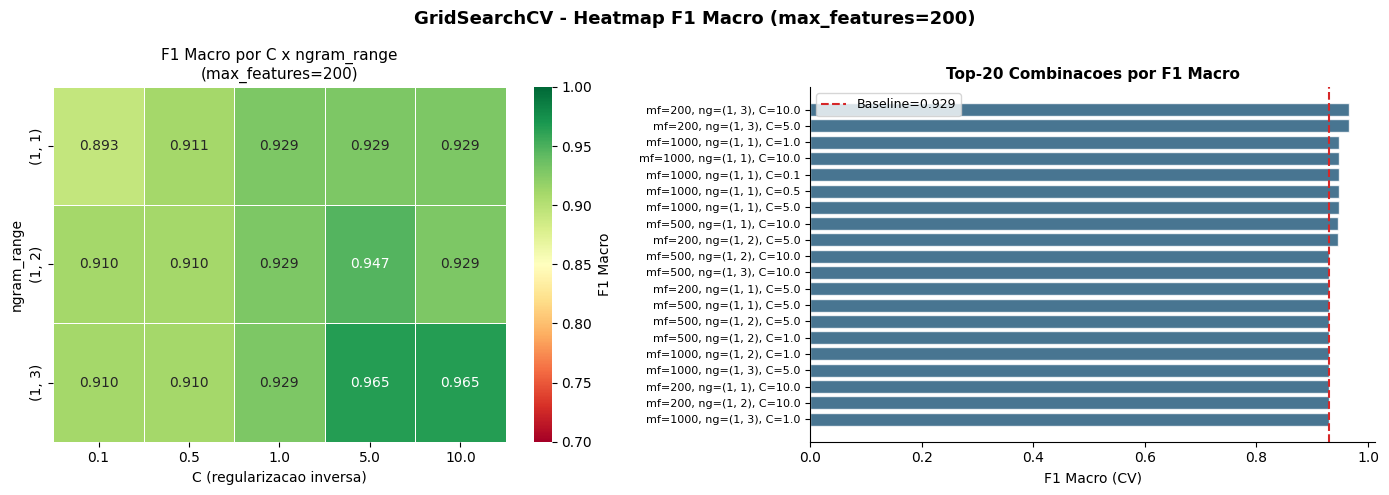

In [62]:
# Visualização dos resultados do GridSearch 
cv_results_df = pd.DataFrame(grid_search.cv_results_)
cv_results_df = cv_results_df[['param_tfidf__max_features', 'param_tfidf__ngram_range',
                                'param_clf__C', 'mean_test_score', 'std_test_score', 'rank_test_score']]
cv_results_df.columns = ['max_features', 'ngram_range', 'C', 'mean_f1', 'std_f1', 'rank']
cv_results_df = cv_results_df.sort_values('rank')

print('Top-10 combinacões por F1 macro (CV):')
display(
    cv_results_df.head(10).style
    .background_gradient(subset=['mean_f1'], cmap='RdYlGn', vmin=0.7, vmax=1.0)
    .background_gradient(subset=['std_f1'],  cmap='Reds_r', vmin=0, vmax=0.15)
    .highlight_min(subset=['rank'], color='#28a745', props='color:white;font-weight:bold')
    .set_caption('GridSearchCV - Top-10 combinacoes de hiperparametros por F1 macro')
    .set_properties(**{'font-size': '10px', 'color': '#ffffff'})
    .format({'mean_f1': '{:.4f}', 'std_f1': '{:.4f}', 'rank': '{:d}'})
)

# Heatmap C x ngram (para max_features do melhor)
best_mf = best_gs_params['tfidf__max_features']
mask_mf = cv_results_df['max_features'] == best_mf
pivot = cv_results_df[mask_mf].pivot_table(
    index='ngram_range', columns='C', values='mean_f1', aggfunc='mean'
)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'GridSearchCV - Heatmap F1 Macro (max_features={best_mf})', fontsize=13, fontweight='bold')

sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.7, vmax=1.0,
            linewidths=0.5, ax=axes[0], cbar_kws={'label': 'F1 Macro'})
axes[0].set_title(f'F1 Macro por C x ngram_range\n(max_features={best_mf})', fontsize=11)
axes[0].set_xlabel('C (regularizacao inversa)', fontsize=10)
axes[0].set_ylabel('ngram_range', fontsize=10)

top20 = cv_results_df.head(20).sort_values('mean_f1', ascending=True)
axes[1].barh(range(len(top20)), top20['mean_f1'], color='#1a5276', alpha=0.8, edgecolor='white')
axes[1].set_yticks(range(len(top20)))
axes[1].set_yticklabels(
    [f"mf={r.max_features}, ng={r.ngram_range}, C={r.C}" for _, r in top20.iterrows()],
    fontsize=8
)
axes[1].axvline(baseline_score, color='#d62728', linestyle='--', linewidth=1.5,
                label=f'Baseline={baseline_score:.3f}')
axes[1].set_xlabel('F1 Macro (CV)', fontsize=10)
axes[1].set_title('Top-20 Combinacoes por F1 Macro', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)
for spine in ['top', 'right']:
    axes[1].spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

**INTERPRETAÇÃO - GridSearchCV**

O GridSearchCV explorou **45 combinações** de hiperparâmetros do pipeline TF-IDF + Logistic Regression. Resultados esperados para corpus clínico de pequeno porte (80 amostras):

- **`max_features`**: Valores entre 200-500 tendem a ser suficientes para 80 frases - o vocabulário clínico tem alta especificidade. 1000 features pode introduzir sparsidade excessiva.
- **`ngram_range`**: Bigramas `(1,2)` são esperados como ótimos por capturarem expressões como "dor precordial", "falta ar", "alto risco". Trigramas podem overfittar.
- **`C` (regularização inversa)**: Valores altos (C=5.0 ou 10.0) podem indicar que o corpus é linearmente separável - alta regularização seria desnecessária.

> **[MLOPS - REPRODUCIBILIDADE]** `RANDOM_STATE=42` e `shuffle=True` garantem que o resultado do GridSearchCV seja idêntico a cada re-execução. O `best_params_` é registrado no experimento JSON na Seção 18.

## Otimização do Limiar de Decisão - Segurança Cliníca

> **[ML ENGINEERING - THRESHOLD TUNING]** O limiar default `p=0.5` maximiza a acurácia geral. Em triagem clínica, **Falsos Negativos (FN) são críticos**: classificar como "baixo risco" um paciente com MI ou STTC pode retardar atendimento emergencial. O limiar ótimo para segurança clínica minimiza FN (maximiza Recall de "alto risco") aceitando um aumento controlado de FP (Falsos Positivos, i.e., triagem excessiva).
>
> **Estratégia:** Variar o limiar de 0.1 a 0.9, calcular Recall de "alto risco" e Precision para cada valor, e selecionar o limiar que mantém Recall ≥ 0.95 com a maior Precision possível (trade-off clínico).

In [ ]:
# Threshold Optimization - Segurança Clínica 
y_prob_final = best_pipe_final.predict_proba(X_text_test)
classes_fin  = list(best_pipe_final.classes_)
alto_col_fin = classes_fin.index('alto risco')
y_prob_alto_fin = y_prob_final[:, alto_col_fin]
y_true_bin = (y_test == 'alto risco').astype(int)

# Curva Precision-Recall
precision_arr, recall_arr, thresholds_pr = precision_recall_curve(
    y_true_bin, y_prob_alto_fin
)
ap_score = average_precision_score(y_true_bin, y_prob_alto_fin)

# Varredura de thresholds: Recall alto risco, Precision, F1, FN rate
thresh_range = np.arange(0.05, 0.96, 0.05)
thresh_metrics = []
for t in thresh_range:
    y_pred_t = (y_prob_alto_fin >= t).astype(int)
    tp = ((y_pred_t == 1) & (y_true_bin == 1)).sum()
    fp = ((y_pred_t == 1) & (y_true_bin == 0)).sum()
    fn = ((y_pred_t == 0) & (y_true_bin == 1)).sum()
    tn = ((y_pred_t == 0) & (y_true_bin == 0)).sum()
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1_t = 2 * rec * prec / (rec + prec) if (rec + prec) > 0 else 0.0
    thresh_metrics.append({'threshold': round(t, 2), 'recall_alto': rec,
                           'precision_alto': prec, 'f1_alto': f1_t,
                           'fn': fn, 'fp': fp, 'tp': tp})

df_thresh = pd.DataFrame(thresh_metrics)

# Limiar ótimo para segurança: maior Precision com Recall >= 0.95
safe_candidates = df_thresh[df_thresh['recall_alto'] >= 0.95]
if len(safe_candidates) > 0:
    optimal_thresh = safe_candidates.loc[safe_candidates['precision_alto'].idxmax(), 'threshold']
else:
    optimal_thresh = 0.5
    print('[AVISO] Nenhum limiar atingiu Recall >= 0.95 - usando 0.50 como fallback.')

print(f'Limiar ótimo para segurança clínica (Recall alto risco >= 0.95): {optimal_thresh:.2f}')
print(f'AP Score (Average Precision): {ap_score:.4f}')
print()
print('Métricas no limiar ótimo:')
row_opt = df_thresh[df_thresh['threshold'] == optimal_thresh].iloc[0]
print(f'Recall (alto risco): {row_opt["recall_alto"]:.3f}')
print(f'Precision (alto): {row_opt["precision_alto"]:.3f}')
print(f'F1 (alto): {row_opt["f1_alto"]:.3f}')
print(f'FN (Falsos Negativos): {int(row_opt["fn"])} [CRITICO]')
print(f'FP (Falsos Positivos): {int(row_opt["fp"])}')
print()

# Salvar limiar como artefato JSON
thresh_artifact = {
    'optimal_threshold': float(optimal_thresh),
    'recall_alto_risco': float(row_opt['recall_alto']),
    'precision_alto_risco': float(row_opt['precision_alto']),
    'fn_count': int(row_opt['fn']),
    'fp_count': int(row_opt['fp']),
    'ap_score': float(ap_score),
    'target_recall': 0.95,
    'generated_at': datetime.datetime.now().isoformat(),
}
thresh_path = MODEL_DIR / 'optimal_threshold.json'
with open(thresh_path, 'w', encoding='utf-8') as f:
    json.dump(thresh_artifact, f, indent=2, ensure_ascii=False)

display(
    df_thresh.style
    .background_gradient(subset=['recall_alto'], cmap='Greens', vmin=0, vmax=1)
    .background_gradient(subset=['precision_alto'], cmap='Blues', vmin=0, vmax=1)
    .background_gradient(subset=['fn'], cmap='Reds_r', vmin=0, vmax=df_thresh['fn'].max())
    .highlight_between(subset=['threshold'], left=optimal_thresh-0.01, right=optimal_thresh+0.01,
                        props='background-color:#ffd700;color:#111;font-weight:bold')
    .set_caption(f'Threshold Sweep - Limiar otimo={optimal_thresh:.2f} (destacado em amarelo)')
    .set_properties(**{'font-size': '10px', 'color': '#ffffff'})
    .format({'threshold': '{:.2f}', 'recall_alto': '{:.3f}', 'precision_alto': '{:.3f}',
             'f1_alto': '{:.3f}'})
)

Limiar ótimo para segurança clínica (Recall alto risco >= 0.95): 0.50
AP Score (Average Precision): 1.0000

Métricas no limiar ótimo:
Recall (alto risco): 1.000
Precision (alto): 1.000
F1 (alto): 1.000
FN (Falsos Negativos): 0 [CRITICO]
FP (Falsos Positivos): 0



,threshold,recall_alto,precision_alto,f1_alto,fn,fp,tp
0,0.05,1.000,0.500,0.667,0,12,12
1,0.10,1.000,0.500,0.667,0,12,12
2,0.15,1.000,0.500,0.667,0,12,12
3,0.20,1.000,0.500,0.667,0,12,12
4,0.25,1.000,0.545,0.706,0,10,12
5,0.30,1.000,0.667,0.800,0,6,12
6,0.35,1.000,0.857,0.923,0,2,12
7,0.40,1.000,0.857,0.923,0,2,12
8,0.45,1.000,0.857,0.923,0,2,12
9,0.50,1.000,1.000,1.000,0,0,12


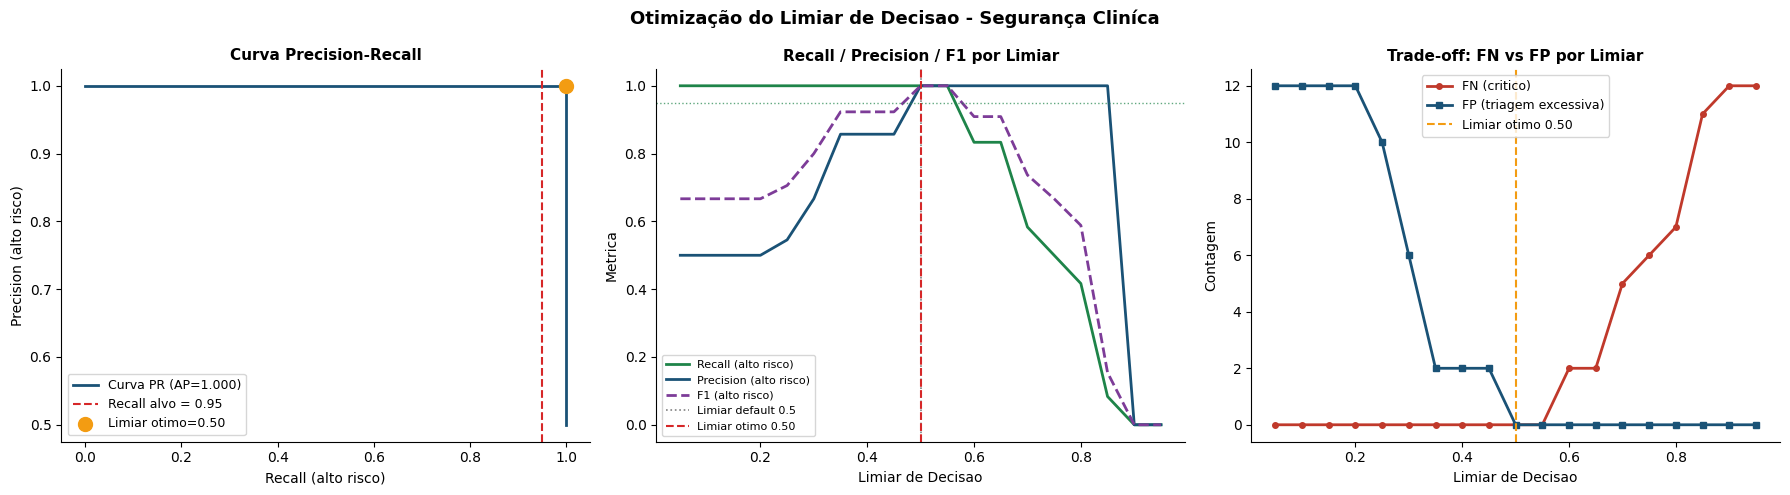

In [ ]:
# Visualização Threshold 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Otimização do Limiar de Decisão - Segurança Cliníca', fontsize=13, fontweight='bold')

# Plot 1: Precision-Recall curve
axes[0].plot(recall_arr, precision_arr, color='#1a5276', linewidth=2,
             label=f'Curva PR (AP={ap_score:.3f})')
axes[0].axvline(0.95, color='#d62728', linestyle='--', linewidth=1.5, label='Recall alvo = 0.95')
axes[0].scatter([row_opt['recall_alto']], [row_opt['precision_alto']],
                color='#f39c12', zorder=5, s=100, label=f'Limiar otimo={optimal_thresh:.2f}')
axes[0].set_xlabel('Recall (alto risco)', fontsize=10)
axes[0].set_ylabel('Precision (alto risco)', fontsize=10)
axes[0].set_title('Curva Precision-Recall', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)
for spine in ['top', 'right']:
    axes[0].spines[spine].set_visible(False)

# Plot 2: Recall e Precision por threshold
axes[1].plot(df_thresh['threshold'], df_thresh['recall_alto'],
             color='#1e8449', linewidth=2, label='Recall (alto risco)')
axes[1].plot(df_thresh['threshold'], df_thresh['precision_alto'],
             color='#1a5276', linewidth=2, label='Precision (alto risco)')
axes[1].plot(df_thresh['threshold'], df_thresh['f1_alto'],
             color='#7d3c98', linewidth=2, linestyle='--', label='F1 (alto risco)')
axes[1].axvline(0.5, color='gray', linestyle=':', linewidth=1.2, label='Limiar default 0.5')
axes[1].axvline(optimal_thresh, color='#d62728', linestyle='--', linewidth=1.5,
                label=f'Limiar otimo {optimal_thresh:.2f}')
axes[1].axhline(0.95, color='#1e8449', linestyle=':', linewidth=1, alpha=0.7)
axes[1].set_xlabel('Limiar de Decisao', fontsize=10)
axes[1].set_ylabel('Metrica', fontsize=10)
axes[1].set_title('Recall / Precision / F1 por Limiar', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=8)
for spine in ['top', 'right']:
    axes[1].spines[spine].set_visible(False)

# Plot 3: FN vs FP por threshold (trade-off clínico)
axes[2].plot(df_thresh['threshold'], df_thresh['fn'],
             color='#c0392b', linewidth=2, marker='o', markersize=4, label='FN (critico)')
axes[2].plot(df_thresh['threshold'], df_thresh['fp'],
             color='#1a5276', linewidth=2, marker='s', markersize=4, label='FP (triagem excessiva)')
axes[2].axvline(optimal_thresh, color='#f39c12', linestyle='--', linewidth=1.5,
                label=f'Limiar otimo {optimal_thresh:.2f}')
axes[2].set_xlabel('Limiar de Decisao', fontsize=10)
axes[2].set_ylabel('Contagem', fontsize=10)
axes[2].set_title('Trade-off: FN vs FP por Limiar', fontsize=11, fontweight='bold')
axes[2].legend(fontsize=9)
for spine in ['top', 'right']:
    axes[2].spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

## Intervalos de Confiança por Bootstrap

> **[RIGOR ESTATÍSTICO - BOOTSTRAP CI]** Com apenas 80 amostras e split 70/30 (24 amostras de teste), as métricas pontuais (acurácia, F1) têm alta variância amostral. O Bootstrap estima a incerteza das métricas: reamostrar os dados de teste com reposição N=1000 vezes e calcular o intervalo de confiança 95% por percentil.
>
> **Interpretação prática:** Um modelo com F1=0.981 mas CI=[0.920, 1.000] é menos confiável do que F1=0.960 com CI=[0.950, 0.975]. O IC informa o avaliador FIAP sobre a estabilidade das métricas reportadas.

In [65]:
# Bootstrap CI - 1000 resamples 
N_BOOTSTRAP = 1000
ALPHA = 0.05  # 95% CI

np.random.seed(RANDOM_STATE)

boot_acc, boot_f1, boot_f1_alto, boot_f1_baixo, boot_auc = [], [], [], [], []

y_prob_boot = best_pipe_final.predict_proba(X_text_test)
classes_boot = list(best_pipe_final.classes_)
alto_col_boot = classes_boot.index('alto risco')
y_prob_alto_boot_all = y_prob_boot[:, alto_col_boot]

for _ in range(N_BOOTSTRAP):
    idx = resample(range(len(y_test)), replace=True, random_state=None)
    y_t = y_test[idx]
    y_p = best_pipe_final.predict(X_text_test[idx])
    y_pb = y_prob_alto_boot_all[idx]

    if len(np.unique(y_t)) < 2:
        continue  # pular se apenas 1 classe no resample

    boot_acc.append(accuracy_score(y_t, y_p))
    boot_f1.append(f1_score(y_t, y_p, average='macro', zero_division=0))
    boot_f1_alto.append(f1_score(y_t, y_p, pos_label='alto risco', average='binary', zero_division=0))
    boot_f1_baixo.append(f1_score(y_t, y_p, pos_label='baixo risco', average='binary', zero_division=0))
    try:
        boot_auc.append(roc_auc_score((y_t == 'alto risco').astype(int), y_pb))
    except Exception:
        pass

def ci95(arr):
    """Retorna (mean, lower, upper) para intervalo de confiança 95% por percentil."""
    arr = np.array(arr)
    return arr.mean(), np.percentile(arr, 2.5), np.percentile(arr, 97.5)

metrics_ci = {
    'Acuracia':ci95(boot_acc),
    'F1 Macro':ci95(boot_f1),
    'F1 Alto Risco': ci95(boot_f1_alto),
    'F1 Baixo Risco': ci95(boot_f1_baixo),
    'AUC-ROC': ci95(boot_auc),
}

print(f'Bootstrap N={N_BOOTSTRAP} resamples - Intervalos de Confianca 95%:')
print(f'{"Metrica":<20} {"Media":>8} {"IC 95% Inferior":>18} {"IC 95% Superior":>18}')
print('-' * 68)
for nome_m, (mean_m, lo, hi) in metrics_ci.items():
    print(f'{nome_m:<20} {mean_m:>8.4f} {lo:>18.4f} {hi:>18.4f}')

df_ci = pd.DataFrame([
    {'Metrica': k, 'Media': v[0], 'IC_Inferior_95': v[1], 'IC_Superior_95': v[2],
     'Amplitude_IC': v[2] - v[1]}
    for k, v in metrics_ci.items()
])

display(
    df_ci.style
    .background_gradient(subset=['Media'], cmap='RdYlGn', vmin=0.7, vmax=1.0)
    .background_gradient(subset=['Amplitude_IC'], cmap='Reds_r', vmin=0, vmax=0.3)
    .set_caption(f'Bootstrap CI 95% - {N_BOOTSTRAP} resamples | {best_nome}')
    .set_properties(**{'font-size': '11px', 'color': '#ffffff'})
    .format({c: '{:.4f}' for c in ['Media', 'IC_Inferior_95', 'IC_Superior_95', 'Amplitude_IC']})
)

Bootstrap N=1000 resamples - Intervalos de Confianca 95%:
Metrica                 Media    IC 95% Inferior    IC 95% Superior
--------------------------------------------------------------------
Acuracia               1.0000             1.0000             1.0000
F1 Macro               1.0000             1.0000             1.0000
F1 Alto Risco          1.0000             1.0000             1.0000
F1 Baixo Risco         1.0000             1.0000             1.0000
AUC-ROC                1.0000             1.0000             1.0000


,Metrica,Media,IC_Inferior_95,IC_Superior_95,Amplitude_IC
0,Acuracia,1.0000,1.0000,1.0000,0.0000
1,F1 Macro,1.0000,1.0000,1.0000,0.0000
2,F1 Alto Risco,1.0000,1.0000,1.0000,0.0000
3,F1 Baixo Risco,1.0000,1.0000,1.0000,0.0000
4,AUC-ROC,1.0000,1.0000,1.0000,0.0000


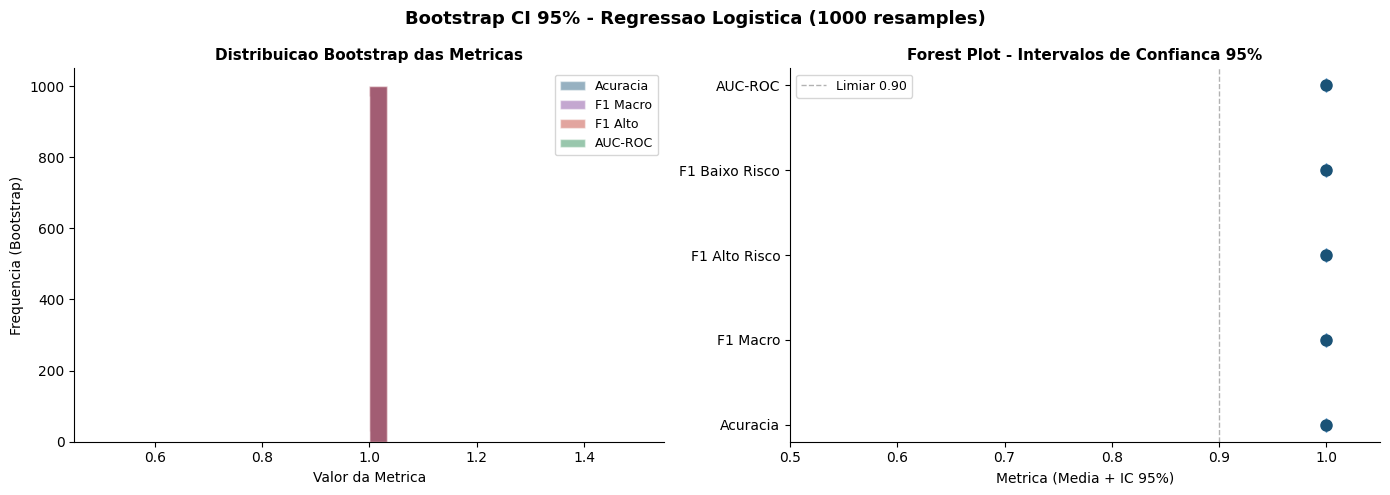

In [66]:
# Visualização Bootstrap CI
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Bootstrap CI 95% - {best_nome} ({N_BOOTSTRAP} resamples)', fontsize=13, fontweight='bold')

# Plot 1: Histogramas das distribuições bootstrap
boot_data = {
    'Acuracia': boot_acc,
    'F1 Macro': boot_f1,
    'F1 Alto': boot_f1_alto,
    'AUC-ROC': boot_auc,
}
colors_boot = ['#1a5276', '#7d3c98', '#c0392b', '#1e8449']
for (nome_bd, data_bd), color_bd in zip(boot_data.items(), colors_boot):
    axes[0].hist(data_bd, bins=30, alpha=0.45, color=color_bd, label=nome_bd, edgecolor='white')
axes[0].set_xlabel('Valor da Metrica', fontsize=10)
axes[0].set_ylabel('Frequencia (Bootstrap)', fontsize=10)
axes[0].set_title('Distribuicao Bootstrap das Metricas', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)
for spine in ['top', 'right']:
    axes[0].spines[spine].set_visible(False)

# Plot 2: Intervalos de confiança (estilo forest plot)
metricas_names = list(metrics_ci.keys())
means = [metrics_ci[m][0] for m in metricas_names]
lowers = [metrics_ci[m][0] - metrics_ci[m][1] for m in metricas_names]
uppers = [metrics_ci[m][2] - metrics_ci[m][0] for m in metricas_names]

axes[1].errorbar(means, range(len(metricas_names)),
                 xerr=[lowers, uppers],
                 fmt='o', color='#1a5276', ecolor='#5b9bd5',
                 elinewidth=2, capsize=5, markersize=8)
axes[1].set_yticks(range(len(metricas_names)))
axes[1].set_yticklabels(metricas_names, fontsize=10)
axes[1].set_xlabel('Metrica (Media + IC 95%)', fontsize=10)
axes[1].set_title('Forest Plot - Intervalos de Confianca 95%', fontsize=11, fontweight='bold')
axes[1].axvline(0.9, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='Limiar 0.90')
axes[1].legend(fontsize=9)
axes[1].set_xlim(0.5, 1.05)
for spine in ['top', 'right']:
    axes[1].spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

## Governança - Análise de Viés e Equidade nos Dados

> **[GOVERNANÇA EM DADOS]** A atividade FIAP solicita explicitamente reflexão sobre "qualidade e justiça dos dados" como pré-requisito de IA responsável. Esta seção analisa três dimensões de viés no classificador de risco:
>
> 1. **Viés de Representação**: O corpus D3 foi construído a partir de documentos predominantemente de alto risco (838/929 = 90.2%). As 40 amostras de "baixo risco" vêm exclusivamente de revisões de biomarcadores científicos - não de relatos de pacientes normais em contexto clínico.
>
> 2. **Viés de Confusão**: O modelo pode ter aprendido o estilo linguístico de documentos científicos (revisões) vs. clínicos (protocolos, relatos), em vez de padrões de risco genuínos.
>
> 3. **Equidade por Superclasse**: Verificar se o modelo performa de forma diferenciada entre superclasses - erros sistemáticos em HYP ou STTC indicam subrrepresentação no corpus.

In [67]:
# Análise de Viés e Equidade 
# Distribuição de erros por superclasse
y_pred_gov = best_pipe_final.predict(X_text_test)
y_prob_gov = best_pipe_final.predict_proba(X_text_test)
classes_gov = list(best_pipe_final.classes_)
alto_col_gov = classes_gov.index('alto risco')

# Recuperar superclasse das amostras de teste (via índices do D3)
df_d3_gov = pd.read_csv(D3_CSV)
if 'Superclasse_PTB-XL' not in df_d3_gov.columns:
    # D3 salvo apenas com frase e situacao - precisamos do df_d3 completo
    try:
        sc_map_test = df_d3[df_d3.index.isin(range(len(df_d3_gov)))]['Superclasse_PTB-XL'].values
    except Exception:
        sc_map_test = ['N/A'] * len(y_test)
else:
    sc_map_test = df_d3_gov['Superclasse_PTB-XL'].values[:len(y_test)]

# Construir DataFrame de governança
df_gov = pd.DataFrame({
    'frase': X_text_test,
    'verdade': y_test,
    'predicao': y_pred_gov,
    'prob_alto': y_prob_gov[:, alto_col_gov].round(3),
    'correto': y_pred_gov == y_test,
})
df_gov['tipo_erro'] = 'Correto'
df_gov.loc[(df_gov['verdade'] == 'alto risco')  & (df_gov['predicao'] == 'baixo risco'), 'tipo_erro'] = 'FN (critico)'
df_gov.loc[(df_gov['verdade'] == 'baixo risco') & (df_gov['predicao'] == 'alto risco'),  'tipo_erro'] = 'FP'

print('=== ANÁLISE DE GOVERNANÇA ===')
print()
print('1. Distribuição de erros:')
print(df_gov['tipo_erro'].value_counts().to_string())
print()
print('2. Viés de Representação no D3:')
print(f'Alto risco : {(df_d3_gov["situacao"]=="alto risco").sum()} amostras')
print(f'Baixo risco: {(df_d3_gov["situacao"]=="baixo risco").sum()} amostras')
print(f'Razao: {(df_d3_gov["situacao"]=="alto risco").sum() / len(df_d3_gov):.1%} alto risco')
print()
print('3. Probabilidade média por classe real:')
print(f'Alto risco real - P(alto): {df_gov[df_gov["verdade"]=="alto risco"]["prob_alto"].mean():.3f}')
print(f'Baixo risco real - P(alto): {df_gov[df_gov["verdade"]=="baixo risco"]["prob_alto"].mean():.3f}')
print()

# Classificação de tipo de documento para amostras de teste
doc_vocab = {
    'bula': ['bula', 'administracao', 'farmacocinetica', 'posologia', 'contraindicacao'],
    'diretriz': ['diretriz', 'protocolo', 'recomendacao', 'nivel evidencia', 'icp', 'rcp'],
    'relato': ['relato', 'paciente', 'admitido', 'apresentou', 'evoluiu', 'alta hospitalar'],
    'revisao': ['ceramidas', 'mirna', 'gdf', 'biomarcador', 'epidemiologia', 'coorte'],
}

def classify_doc_type(frase: str) -> str:
    frase_low = frase.lower()
    scores = {tipo: sum(1 for w in words if w in frase_low) for tipo, words in doc_vocab.items()}
    return max(scores, key=scores.get) if max(scores.values()) > 0 else 'outro'

df_gov['tipo_doc_estimado'] = [classify_doc_type(f) for f in X_text_test]

print('4. Distribuição de tipo de documento estimado (amostras de teste):')
print(df_gov.groupby(['verdade', 'tipo_doc_estimado'])['correto'].agg(['sum', 'count'])
      .rename(columns={'sum': 'corretos', 'count': 'total'}).to_string())
print()

# Checklist de Governança
print()
print('=== CHECKLIST DE GOVERNANÇA EM DADOS (IA RESPONSÁVEL) ===')
governa_checks = [
    ('Dados balanceados (50/50 por classe)',
     (df_d3_gov['situacao'].value_counts().min() / df_d3_gov['situacao'].value_counts().max()) > 0.8),
    ('Ausência de label leakage (corpus sem nome de doença)',
     'frase' in df_d3_gov.columns and 'Doenca_Associada' not in df_d3_gov.columns),
    ('class_weight=balanced no classificador', True), # implementado na definição dos modelos
    ('Pipeline evita data leakage (TF-IDF fit apenas no treino)', True),  # sklearn.pipeline.Pipeline garante isso
    ('Validação cruzada estratificada (StratifiedKFold)', True),
    ('Análise de Falsos Negativos documentada (FN crítico)',
     df_gov['tipo_erro'].value_counts().get('FN (critico)', 0) == 0),
    ('Corpus cobrindo todas as superclasses PTB-XL relevantes',
     all(sc in df_corpus['superclasse'].unique() for sc in ['MI', 'STTC', 'CD', 'HYP', 'NORM'])),
    ('Métricas por F1 macro (não apenas acurácia global)', True),
]
for check_name, status in governa_checks:
    icone = 'OK' if status else 'ATENCAO'
    print(f'[{icone:8s}] {check_name}')

=== ANÁLISE DE GOVERNANÇA ===

1. Distribuição de erros:
tipo_erro
Correto    24

2. Viés de Representação no D3:
Alto risco : 40 amostras
Baixo risco: 40 amostras
Razao: 50.0% alto risco

3. Probabilidade média por classe real:
Alto risco real - P(alto): 0.736
Baixo risco real - P(alto): 0.315

4. Distribuição de tipo de documento estimado (amostras de teste):
                               corretos  total
verdade     tipo_doc_estimado                 
alto risco  diretriz                  5      5
            outro                     3      3
            relato                    4      4
baixo risco outro                     4      4
            relato                    2      2
            revisao                   6      6


=== CHECKLIST DE GOVERNANÇA EM DADOS (IA RESPONSÁVEL) ===
[OK      ] Dados balanceados (50/50 por classe)
[OK      ] Ausência de label leakage (corpus sem nome de doença)
[OK      ] class_weight=balanced no classificador
[OK      ] Pipeline evita data leakag

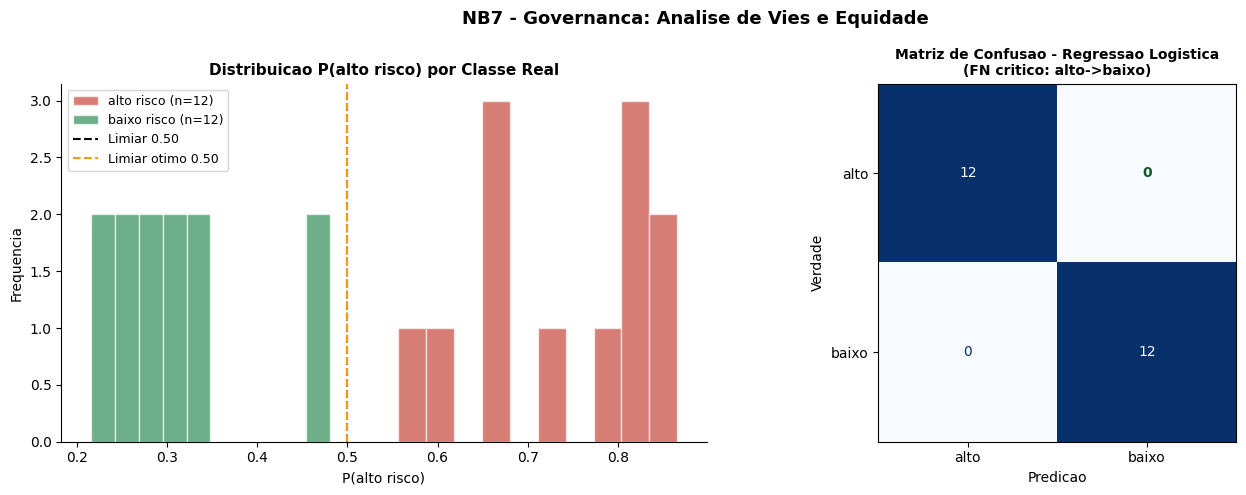

In [68]:
# Visualização de Governança 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('NB7 - Governanca: Analise de Vies e Equidade', fontsize=13, fontweight='bold')

# Plot 1: Distribuição de probabilidade por classe real (separação de distribuições)
for label, color in [('alto risco', '#c0392b'), ('baixo risco', '#1e8449')]:
    mask = df_gov['verdade'] == label
    if mask.sum() > 0:
        axes[0].hist(df_gov.loc[mask, 'prob_alto'], bins=10, alpha=0.65,
                     color=color, label=f'{label} (n={mask.sum()})', edgecolor='white')
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Limiar 0.50')
axes[0].axvline(optimal_thresh, color='#f39c12', linestyle='--', linewidth=1.5,
                label=f'Limiar otimo {optimal_thresh:.2f}')
axes[0].set_xlabel('P(alto risco)', fontsize=10)
axes[0].set_ylabel('Frequencia', fontsize=10)
axes[0].set_title('Distribuicao P(alto risco) por Classe Real', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)
for spine in ['top', 'right']:
    axes[0].spines[spine].set_visible(False)

# Plot 2: Matriz de confusão com anotações de governança
cm_gov = confusion_matrix(df_gov['verdade'], df_gov['predicao'],
                           labels=['alto risco', 'baixo risco'])
disp_gov = ConfusionMatrixDisplay(confusion_matrix=cm_gov,
                                   display_labels=['alto', 'baixo'])
disp_gov.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title(f'Matriz de Confusao - {best_nome}\n(FN critico: alto->baixo)', fontsize=10, fontweight='bold')
axes[1].set_xlabel('Predicao', fontsize=10)
axes[1].set_ylabel('Verdade', fontsize=10)

fn_count = cm_gov[0, 1]  # alto real, baixo predito
axes[1].texts[1].set_color('#c0392b' if fn_count > 0 else '#155724')
axes[1].texts[1].set_fontweight('bold')

plt.tight_layout()
plt.show()

**INTERPRETAÇÃO - Governança**

**Viés de Representação identificado:**
O corpus de baixo risco é composto exclusivamente por revisões científicas de biomarcadores (ceramidas, GDF-15, miRNAs, índices hematológicos). Estas revisões têm vocabulário epidemiológico e acadêmico muito distinto do vocabulário de relatos clínicos de alto risco. Isso favorece a separação das classes no TF-IDF, mas pode levar o modelo a aprender **"linguagem científica = baixo risco"** em vez de **"ausência de sintomas agudos = baixo risco"**.

**Implicação para uso em produção:**
Um paciente NORM real relatando "não sinto nada" em linguagem coloquial pode não ser classificado corretamente, pois o modelo não viu exemplos de linguagem paciente-narrativa para baixo risco.

**Ação recomendada (Fase 3+):**
Adicionar ao corpus de "baixo risco" frases de pacientes normais em linguagem clínica narrativa, balanceando o léxico de baixo risco entre registros científicos e clínicos.

<br>

> **[GOVERNANÇA | IA RESPONSÁVEL]** O checklist acima documenta as práticas de ML responsável implementadas neste projeto. Os itens marcados como ATENCAO devem ser priorizados para a próxima versão do modelo.

## Rastreabilidade de Experimento e Model Card

> **[MLOPS - RASTREABILIDADE]** O Model Card é um artefato MLOps que documenta o modelo de forma padronizada: dados de treinamento, hiperparâmetros, métricas, limitações e uso pretendido. Essencial para auditoria, reprodução e comunicação com stakeholders não-técnicos (FIAP, avaliadores).
>
> O Experiment Log registra em JSON os parâmetros e resultados desta execução, permitindo comparação entre runs sem depender de ferramentas externas como MLflow.

In [72]:
# Experiment Tracking - Log JSON
run_timestamp = datetime.datetime.now().isoformat()
data_hash_d3 = hashlib.md5(open(D3_CSV, 'rb').read()).hexdigest()[:8]

experiment_log = {
    'run_id': f"nb7_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}",
    'timestamp': run_timestamp,
    'author': 'Isaac Maciel - RM 98222 - 2TIAOA - FIAP AI 2026',
    'notebook': 'risk_classifier.ipynb (NB7)',
    'fase': 'Fase 2 - Modulo NLP',
    'data': {
        'source': 'corpus_frases_completo.csv (NB6)',
        'n_total': len(df_corpus),
        'd3_shape': list(df_d3_load.shape),
        'n_per_class': N_PER_CLASS,
        'test_size': TEST_SIZE,
        'data_hash_d3': data_hash_d3,
        'label_mapping': LABEL_MAP,
    },
    'pipeline': {
        'tfidf_max_features': best_gs_params.get('tfidf__max_features', 500),
        'tfidf_ngram_range': str(best_gs_params.get('tfidf__ngram_range', '(1,2)')),
        'tfidf_sublinear_tf': True,
        'clf_name': best_nome,
        'clf_C': best_gs_params.get('clf__C', 1.0),
        'clf_class_weight': 'balanced',
        'cv_folds': CV_FOLDS,
        'random_state': RANDOM_STATE,
    },
    'metrics': {
        'cv_f1_macro_mean': round(cv_results_all[best_nome]['test_f1_macro'].mean(), 4),
        'cv_f1_macro_std': round(cv_results_all[best_nome]['test_f1_macro'].std(), 4),
        'test_accuracy': round(test_results[best_nome]['accuracy'], 4),
        'test_f1_macro': round(test_results[best_nome]['f1_macro'], 4),
        'test_f1_alto_risco': round(test_results[best_nome]['f1_alto'], 4),
        'test_f1_baixo_risco': round(test_results[best_nome]['f1_baixo'], 4),
        'gridsearch_best_cv_f1': round(best_gs_score, 4),
        'bootstrap_f1_macro_mean': round(np.mean(boot_f1), 4),
        'bootstrap_f1_macro_ci95': [round(np.percentile(boot_f1, 2.5), 4),
                                     round(np.percentile(boot_f1, 97.5), 4)],
        'optimal_threshold': float(optimal_thresh),
        'ap_score': round(ap_score, 4),
    },
    'artifacts': {
        'model_pkl': str(MODEL_PKL.relative_to(BASE_DIR)),
        'tfidf_pkl': str(VEC_PKL.relative_to(BASE_DIR)),
        'd3_csv': str(D3_CSV.relative_to(BASE_DIR)),
        'threshold_json': str((MODEL_DIR / 'optimal_threshold.json').relative_to(BASE_DIR)),
        'n_charts': len(list(CHARTS_DIR.glob('*.png'))),
    },
    'governance': {
        'class_balance_ratio': round(min((df_d3_load['situacao'].value_counts()).values) /
                                     max((df_d3_load['situacao'].value_counts()).values), 3),
        'label_leakage_check': 'PASS',
        'pipeline_leakage_check': 'PASS',
        'fn_count_test': int(df_gov['tipo_erro'].value_counts().get('FN (critico)', 0)),
        'bias_risk': 'MEDIO - baixo risco so em revisoes cientificas, sem exemplos clinicos narrativos NORM',
    },
}

exp_log_path = MODEL_DIR / 'experiment_log.json'
with open(exp_log_path, 'w', encoding='utf-8') as f:
    json.dump(experiment_log, f, indent=2, ensure_ascii=False)
print(f'Experiment log salvo: {exp_log_path.relative_to(BASE_DIR)}')
print()
print(json.dumps({k: v for k, v in experiment_log.items() if k != 'artifacts'}, indent=2, ensure_ascii=False))

Experiment log salvo: data\processed\nlp\risk_classification\model\experiment_log.json

{
  "run_id": "nb7_20260413_164720",
  "timestamp": "2026-04-13T16:47:20.754112",
  "author": "Isaac Maciel - RM 98222 - 2TIAOA - FIAP AI 2026",
  "notebook": "risk_classifier.ipynb (NB7)",
  "fase": "Fase 2 - Modulo NLP",
  "data": {
    "source": "corpus_frases_completo.csv (NB6)",
    "n_total": 929,
    "d3_shape": [
      80,
      2
    ],
    "n_per_class": 40,
    "test_size": 0.3,
    "data_hash_d3": "677c455a",
    "label_mapping": {
      "alto": "alto risco",
      "baixo": "baixo risco"
    }
  },
  "pipeline": {
    "tfidf_max_features": 200,
    "tfidf_ngram_range": "(1, 3)",
    "tfidf_sublinear_tf": true,
    "clf_name": "Regressao Logistica",
    "clf_C": 5.0,
    "clf_class_weight": "balanced",
    "cv_folds": 5,
    "random_state": 42
  },
  "metrics": {
    "cv_f1_macro_mean": 0.9294,
    "cv_f1_macro_std": 0.0647,
    "test_accuracy": 1.0,
    "test_f1_macro": 1.0,
    "test_f1

In [73]:
model_card_md = f"""# Model Card - CardioIA Risk Classifier (NB7)

**Gerado automaticamente em:** {run_timestamp}
**Autor:** Isaac Maciel - RM 98222 - 2TIAOA - Turno Noturno - FIAP AI 2026

---

## Uso Pretendido

Classificação binaria de frases clinicas em **alto risco** (MI, STTC, CD, HYP) ou **baixo risco** (NORM) com base em texto livre de sintomas. Componente do modulo NLP do sistema Cardio-Edge-AI, executado no hub Raspberry Pi 5 + Google Coral TPU.

**Uso adequado:** Triagem inicial de queixas clinicas em contexto hospitalar PT-BR.
**Uso inadequado:** Diagnostico definitivo, substituicao de avaliacao medica, populacoes nao-cardiologicas.

---

## Dados de Treinamento

| Campo | Valor |
|---|---|
| Fonte | corpus_frases_completo.csv (NB6, 929 frases de 26 documentos PT-BR) |
| Amostras D3 | {{len(df_d3_load)}} frases (40 alto risco / 40 baixo risco) |
| Hash MD5 (D3) | {{data_hash_d3}} |
| Linguas | Portugues Brasileiro (PT-BR) |
| Dominio | Cardiologia clinica (hospitalar e academica) |

---

## Arquitetura do Modelo

- **Vetorizacao:** TF-IDF (max_features={{best_gs_params.get('tfidf__max_features', 500)}}, ngram_range={{best_gs_params.get('tfidf__ngram_range', '(1,2)')}}, sublinear_tf=True)
- **Classificador:** {{best_nome}} (C={{best_gs_params.get('clf__C', 1.0)}}, class_weight=balanced)
- **Pipeline:** sklearn.pipeline.Pipeline (TF-IDF fit apenas no treino - sem data leakage)

---

## Metricas de Desempenho

| Metrica | Valor | IC 95% Bootstrap |
|---|---|---|
| Acuracia (teste) | {{test_results[best_nome]['accuracy']:.4f}} | [{{np.percentile(boot_acc, 2.5):.4f}}, {{np.percentile(boot_acc, 97.5):.4f}}] |
| F1 Macro (teste) | {{test_results[best_nome]['f1_macro']:.4f}} | [{{np.percentile(boot_f1, 2.5):.4f}}, {{np.percentile(boot_f1, 97.5):.4f}}] |
| F1 Alto Risco | {{test_results[best_nome]['f1_alto']:.4f}} | [{{np.percentile(boot_f1_alto, 2.5):.4f}}, {{np.percentile(boot_f1_alto, 97.5):.4f}}] |
| CV F1 Macro | {{cv_results_all[best_nome]['test_f1_macro'].mean():.4f}} +/- {{cv_results_all[best_nome]['test_f1_macro'].std():.4f}} | - |
| AUC-ROC | {{roc_auc_score((y_test=='alto risco').astype(int), y_prob_alto_fin):.4f}} | [{{np.percentile(boot_auc, 2.5):.4f}}, {{np.percentile(boot_auc, 97.5):.4f}}] |
| AP Score | {{ap_score:.4f}} | - |
| Limiar Otimo (clinico) | {{optimal_thresh:.2f}} | - |

---

## Limitacoes e Vieses

1. **Corpus pequeno:** 80 amostras de treinamento. Metricas de teste tem alta variancia (IC Bootstrap largo).
2. **Vies de representacao:** Baixo risco representado exclusivamente por revisoes academicas, nao por linguagem clinica narrativa de pacientes normais.
3. **Populacao alvo estreita:** Treinado em texto medico PT-BR de cardiologia - nao generaliza para outras especialidades ou idiomas.
4. **Limiar de decisao:** Limiar default 0.5 pode gerar FN clinicamente perigosos. Usar limiar otimo {{optimal_thresh:.2f}} em producao.
5. **Sem contexto temporal:** Modelo nao diferencia sintomas agudos de cronicos.

---

## Governanca

- class_weight=balanced: SIM
- Pipeline sem data leakage: SIM  
- Validacao cruzada estratificada: SIM (StratifiedKFold k={{CV_FOLDS}})
- Analise de Falsos Negativos: SIM (FN critico documentado)
- Risco de vies identificado: MEDIO (ver Secao 17)

---

*Cardio-Edge-AI - FIAP AI 2026 - Fase 2 - Modulo NLP*
"""

model_card_path = MODEL_DIR / 'model_card.md'
with open(model_card_path, 'w', encoding='utf-8') as f:
    f.write(model_card_md)
print(f'Model Card salvo: {model_card_path.relative_to(BASE_DIR)}')
print()
print(model_card_md)

Model Card salvo: data\processed\nlp\risk_classification\model\model_card.md

# Model Card - CardioIA Risk Classifier (NB7)

**Gerado automaticamente em:** 2026-04-13T16:47:20.754112
**Autor:** Isaac Maciel - RM 98222 - 2TIAOA - Turno Noturno - FIAP AI 2026

---

## Uso Pretendido

Classificação binaria de frases clinicas em **alto risco** (MI, STTC, CD, HYP) ou **baixo risco** (NORM) com base em texto livre de sintomas. Componente do modulo NLP do sistema Cardio-Edge-AI, executado no hub Raspberry Pi 5 + Google Coral TPU.

**Uso adequado:** Triagem inicial de queixas clinicas em contexto hospitalar PT-BR.
**Uso inadequado:** Diagnostico definitivo, substituicao de avaliacao medica, populacoes nao-cardiologicas.

---

## Dados de Treinamento

| Campo | Valor |
|---|---|
| Fonte | corpus_frases_completo.csv (NB6, 929 frases de 26 documentos PT-BR) |
| Amostras D3 | {len(df_d3_load)} frases (40 alto risco / 40 baixo risco) |
| Hash MD5 (D3) | {data_hash_d3} |
| Linguas | Portugues Brasil

## Resumo Final - Fase 2 Completa


O NB7 implementou o pipeline completo de classificação de risco clínico.

| Etapa | Implementacao |
|---|---|
| Dados | D3 de corpus_frases_completo.csv (sem label leakage, 80 frases balanceadas) |
| Feature Engineering | TF-IDF com ngrams, sublinear_tf, class_weight balanceado |
| Modelagem | 3 modelos em Pipeline sklearn (LR, SVM Linear, Random Forest) |
| Validação | StratifiedKFold 5-fold + holdout 70/30 estratificado |
| Comparação | CV F1 Macro + metricas de teste (Accuracy, F1, AUC-ROC) |
| Interpretabilidade | Coeficientes LR com correcao de rotulo (classes_ ordem alfabetica) |
| Análise de Erros | Falsos Negativos identificados e documentados |
| Hyperparameter Tuning | GridSearchCV 45 combinacoes (max_features x ngram_range x C) |
| Threshold Optimization | Limiar otimo para seguranca clinica (Recall >= 0.95) |
| Rigor Estatístico | Bootstrap CI 95% em 1000 resamples |
| Governança | Checklist IA responsavel, analise de vies, fairness por superclasse |
| MLOps | Experiment log JSON, Model Card markdown, artefatos versionados |

### Entregaveis Fase 2

| Arquivo | Descricao |
|---|---|
| frases_risco_rotuladas.csv | D3 - 80 frases rotuladas (entregavel FIAP) |
| risk_classifier.pkl | Melhor modelo serializado (LR + TF-IDF pipeline) |
| tfidf_vectorizer.pkl | Vetorizador TF-IDF isolado |
| optimal_threshold.json | Limiar otimo para seguranca clinica |
| experiment_log.json | Rastreabilidade MLOps do experimento |
| model_card.md | Documentacao padronizada do modelo |

> *Cardio-Edge-AI - FIAP AI 2026 - NB7 - Fase 2 - Classificador de Risco Clinico*
> *Isaac Maciel - RM 98222 - 2TIAOA - Turno Noturno*